In [1]:
# =========================
# 1) IMPORTS
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)

In [2]:
# =========================
# 2) FILE PATH
# =========================

file_path = "/Users/williamferris/Desktop/Data400MP/Fullspreadsheetdata400.xlsx"

In [5]:
# =========================
# 3) HELPER FUNCTIONS
# =========================

def clean_ticker(raw_ticker):
    """
    Convert Bloomberg-style tickers like:
    'AAPL UW Equity' -> 'AAPL'
    'A UN Equity'    -> 'A'
    'BRK/B UN Equity' stays 'BRK/B'
    """
    if pd.isna(raw_ticker):
        return np.nan
    
    raw_ticker = str(raw_ticker).strip()
    
    if raw_ticker == "" or raw_ticker.lower() == "nan":
        return np.nan
    
    # remove special benchmark row later, but keep original for now
    parts = raw_ticker.split()
    if len(parts) >= 1:
        return parts[0].strip()
    
    return raw_ticker


def parse_bloomberg_sheet(file_path, sheet_name):
    """
    Parses sheets formatted like:
    col 0 = ticker / security name
    col 2 = variable name
    cols 4:18 = yearly values
    row 3 contains dates
    """
    raw = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

    # row 3 contains the date headers in columns 4 onward
    date_row = raw.iloc[3, 4:]
    years = pd.to_datetime(date_row, errors="coerce").dt.year.tolist()

    # keep only columns 0, 2, and the date columns
    keep_cols = [0, 2] + list(range(4, 4 + len(years)))
    df = raw.loc[4:, keep_cols].copy()

    # rename columns
    df.columns = ["security", "variable"] + years

    # drop blank rows
    df = df[df["security"].notna()].copy()
    df = df[df["variable"].notna()].copy()

    # remove the header-like "Dates" variable row
    df = df[df["variable"] != "Dates"].copy()

    # clean ticker
    df["ticker"] = df["security"].apply(clean_ticker)

    # melt to long format
    long_df = df.melt(
        id_vars=["security", "ticker", "variable"],
        var_name="year",
        value_name="value"
    )

    # numeric conversion
    long_df["value"] = pd.to_numeric(long_df["value"], errors="coerce")
    long_df["year"] = pd.to_numeric(long_df["year"], errors="coerce").astype("Int64")

    return long_df


def wide_panel_from_long(long_df):
    """
    Converts long format:
    security | ticker | variable | year | value
    into wide stock-year panel:
    security | ticker | year | variable1 | variable2 | ...
    """
    panel = long_df.pivot_table(
        index=["security", "ticker", "year"],
        columns="variable",
        values="value",
        aggfunc="first"
    ).reset_index()

    panel.columns.name = None
    return panel


def missingness_report(df, id_cols=("security", "ticker", "year")):
    """
    Returns missingness summary for all feature columns.
    """
    feature_cols = [c for c in df.columns if c not in id_cols]
    
    report = pd.DataFrame({
        "column_name": feature_cols,
        "missing_count": [df[c].isna().sum() for c in feature_cols],
        "missing_pct": [df[c].isna().mean() for c in feature_cols],
        "non_null_count": [df[c].notna().sum() for c in feature_cols]
    }).sort_values("missing_pct")
    
    return report.reset_index(drop=True)

In [7]:
# =========================
# 4) PARSE SHEETS
# =========================

sheet1_long = parse_bloomberg_sheet(file_path, "Sheet1")
sheet2_long = parse_bloomberg_sheet(file_path, "Sheet2")

print("Sheet1 long shape:", sheet1_long.shape)
print("Sheet2 long shape:", sheet2_long.shape)

display(sheet1_long.head())
display(sheet2_long.head())

Sheet1 long shape: (129280, 5)
Sheet2 long shape: (404000, 5)


,security,ticker,variable,year,value
0,SPX Index,SPX,CUR_MKT_CAP,2011,1.166203e+07
1,A UN Equity,A,CUR_MKT_CAP,2011,1.216001e+04
2,AAPL UW Equity,AAPL,CUR_MKT_CAP,2011,3.764106e+05
3,ABBV UN Equity,ABBV,CUR_MKT_CAP,2011,NaN
4,ABNB UW Equity,ABNB,CUR_MKT_CAP,2011,NaN


,security,ticker,variable,year,value
0,SPX Index,SPX,PX_LAST,2011,1257.6100
1,A UN Equity,A,PX_LAST,2011,24.9780
2,AAPL UW Equity,AAPL,PX_LAST,2011,14.4643
3,ABBV UN Equity,ABBV,PX_LAST,2011,NaN
4,ABNB UW Equity,ABNB,PX_LAST,2011,NaN


In [9]:
# =========================
# 5) COMBINE LONG DATA
# =========================

all_long = pd.concat([sheet1_long, sheet2_long], ignore_index=True)

print("Combined long shape:", all_long.shape)
print("Unique variables:", all_long["variable"].nunique())
print(sorted(all_long["variable"].dropna().unique().tolist()))

Combined long shape: (533280, 5)
Unique variables: 33
['BEST_CAPEX', 'BEST_CURRENT_EV_BEST_SALES', 'BEST_EPS', 'BS_TOT_ASSET', 'CF_FREE_CASH_FLOW_FIRM', 'CURRENT_EV_TO_T12M_EBITDA', 'CURR_ENTP_VAL', 'CUR_MKT_CAP', 'EARN_YLD', 'EBITDA_MARGIN', 'EQY_RAW_BETA', 'FREE_FLOAT_MARKET_CAP', 'GROSS_MARGIN', 'INDX_PX_SALES', 'INST_INVSTRS_NET_BUY_VAL', 'INTEREST_COVERAGE_RATIO_MEDIAN', 'LAST_CLOSE_TRR_YTD', 'LQA_BID_ASK_SPREAD', 'MSCI_LT_SPS_G_RATE', 'OPER_MARGIN', 'PE_RATIO', 'PROF_MARGIN', 'PX_LAST', 'RETURN_COM_EQY', 'RETURN_ON_ASSET', 'RETURN_SHARPE_RATIO', 'TOTAL_ETF_ASSET_UNDER_MANAGEMENT', 'TOT_DEBT_TO_TOT_EQY', 'TURNOVER', 'VOLATILITY_30D', 'VOLATILITY_360D', 'VOLATILITY_90D', 'VOLUME_AVG_30D']


In [11]:
# =========================
# 6) CONVERT TO WIDE PANEL
# =========================

panel_df = wide_panel_from_long(all_long)

print("Wide panel shape:", panel_df.shape)
display(panel_df.head())

Wide panel shape: (7298, 28)


,security,ticker,year,BEST_CAPEX,BEST_CURRENT_EV_BEST_SALES,BEST_EPS,BS_TOT_ASSET,CF_FREE_CASH_FLOW_FIRM,CURRENT_EV_TO_T12M_EBITDA,CURR_ENTP_VAL,CUR_MKT_CAP,EARN_YLD,EBITDA_MARGIN,FREE_FLOAT_MARKET_CAP,GROSS_MARGIN,INDX_PX_SALES,OPER_MARGIN,PE_RATIO,PROF_MARGIN,PX_LAST,RETURN_COM_EQY,RETURN_ON_ASSET,TOT_DEBT_TO_TOT_EQY,TURNOVER,VOLATILITY_30D,VOLATILITY_360D,VOLATILITY_90D,VOLUME_AVG_30D
0,A UN Equity,A,2011,NaN,NaN,NaN,9696.0,691.8902,20.1188,15451.2415,12160.0137,6.3106,14.1073,NaN,53.8207,NaN,10.3968,15.8464,12.5643,24.9780,23.8577,7.9039,114.0606,7.928214e+09,23.034,29.963,25.421,869046.0333
1,A UN Equity,A,2012,NaN,NaN,NaN,9057.0,1156.3333,20.1188,15451.2415,14244.4388,6.3106,20.0151,NaN,53.3485,NaN,16.1905,15.8464,15.2986,29.2757,26.8577,10.7929,50.6256,7.928214e+09,23.034,29.963,25.421,869046.0333
2,A UN Equity,A,2013,NaN,NaN,NaN,9057.0,1156.3333,8.1767,10826.0137,18976.1282,10.9916,20.0151,NaN,53.3485,NaN,16.1905,9.0978,15.2986,40.8958,26.8577,10.7929,50.6256,1.040959e+10,45.890,44.833,60.069,710228.5000
3,A UN Equity,A,2014,NaN,NaN,NaN,10536.0,1156.3333,8.1767,10826.0137,13728.0748,10.9916,20.7057,NaN,52.5518,NaN,16.3167,9.0978,16.8125,40.9400,24.2993,11.7695,45.5545,1.040959e+10,45.890,44.833,60.069,710228.5000
4,A UN Equity,A,2015,NaN,NaN,NaN,10536.0,1156.3333,10.0412,14258.4388,13888.0653,9.4589,20.7057,NaN,52.5518,NaN,16.3167,10.5721,16.8125,41.8100,24.2993,11.7695,45.5545,7.223454e+09,29.745,43.744,24.671,849090.8000


In [13]:
# =========================
# 7) BASIC CLEANING
# =========================

# remove benchmark row
panel_df = panel_df[panel_df["security"] != "SPX Index"].copy()

# drop rows with no ticker or year
panel_df = panel_df[panel_df["ticker"].notna()].copy()
panel_df = panel_df[panel_df["year"].notna()].copy()

# ensure year is int
panel_df["year"] = panel_df["year"].astype(int)

# sort
panel_df = panel_df.sort_values(["ticker", "year"]).reset_index(drop=True)

print("Panel shape after cleaning:", panel_df.shape)
display(panel_df.head())

Panel shape after cleaning: (7283, 28)


,security,ticker,year,BEST_CAPEX,BEST_CURRENT_EV_BEST_SALES,BEST_EPS,BS_TOT_ASSET,CF_FREE_CASH_FLOW_FIRM,CURRENT_EV_TO_T12M_EBITDA,CURR_ENTP_VAL,CUR_MKT_CAP,EARN_YLD,EBITDA_MARGIN,FREE_FLOAT_MARKET_CAP,GROSS_MARGIN,INDX_PX_SALES,OPER_MARGIN,PE_RATIO,PROF_MARGIN,PX_LAST,RETURN_COM_EQY,RETURN_ON_ASSET,TOT_DEBT_TO_TOT_EQY,TURNOVER,VOLATILITY_30D,VOLATILITY_360D,VOLATILITY_90D,VOLUME_AVG_30D
0,A UN Equity,A,2011,NaN,NaN,NaN,9696.0,691.8902,20.1188,15451.2415,12160.0137,6.3106,14.1073,NaN,53.8207,NaN,10.3968,15.8464,12.5643,24.9780,23.8577,7.9039,114.0606,7.928214e+09,23.034,29.963,25.421,869046.0333
1,A UN Equity,A,2012,NaN,NaN,NaN,9057.0,1156.3333,20.1188,15451.2415,14244.4388,6.3106,20.0151,NaN,53.3485,NaN,16.1905,15.8464,15.2986,29.2757,26.8577,10.7929,50.6256,7.928214e+09,23.034,29.963,25.421,869046.0333
2,A UN Equity,A,2013,NaN,NaN,NaN,9057.0,1156.3333,8.1767,10826.0137,18976.1282,10.9916,20.0151,NaN,53.3485,NaN,16.1905,9.0978,15.2986,40.8958,26.8577,10.7929,50.6256,1.040959e+10,45.890,44.833,60.069,710228.5000
3,A UN Equity,A,2014,NaN,NaN,NaN,10536.0,1156.3333,8.1767,10826.0137,13728.0748,10.9916,20.7057,NaN,52.5518,NaN,16.3167,9.0978,16.8125,40.9400,24.2993,11.7695,45.5545,1.040959e+10,45.890,44.833,60.069,710228.5000
4,A UN Equity,A,2015,NaN,NaN,NaN,10536.0,1156.3333,10.0412,14258.4388,13888.0653,9.4589,20.7057,NaN,52.5518,NaN,16.3167,10.5721,16.8125,41.8100,24.2993,11.7695,45.5545,7.223454e+09,29.745,43.744,24.671,849090.8000


In [15]:
# =========================
# 8) QUICK STRUCTURE CHECKS
# =========================

print("Years in dataset:")
print(sorted(panel_df["year"].unique().tolist()))

print("\nNumber of unique tickers:")
print(panel_df["ticker"].nunique())

print("\nRows per year:")
print(panel_df.groupby("year")["ticker"].nunique())

Years in dataset:
[2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

Number of unique tickers:
504

Rows per year:
year
2011    458
2012    464
2013    465
2014    471
2015    472
2016    475
2017    481
2018    491
2019    496
2020    498
2021    501
2022    502
2023    502
2024    503
2025    504
Name: ticker, dtype: int64


In [17]:
# =========================
# 9) MISSINGNESS REPORT
# =========================

missing_report = missingness_report(panel_df)

display(missing_report)

# save for review
missing_report.to_csv("missingness_report_before_filter.csv", index=False)

,column_name,missing_count,missing_pct,non_null_count
0,PROF_MARGIN,11,0.001510,7272
1,OPER_MARGIN,11,0.001510,7272
2,BS_TOT_ASSET,41,0.005630,7242
3,RETURN_ON_ASSET,107,0.014692,7176
4,TOT_DEBT_TO_TOT_EQY,108,0.014829,7175
5,RETURN_COM_EQY,252,0.034601,7031
6,CUR_MKT_CAP,401,0.055060,6882
7,PX_LAST,447,0.061376,6836
8,EBITDA_MARGIN,515,0.070713,6768
9,VOLUME_AVG_30D,631,0.086640,6652


In [19]:
# =========================
# 10) DROP VERY BAD VARIABLES
# =========================

id_cols = ["security", "ticker", "year"]

feature_cols = [c for c in panel_df.columns if c not in id_cols]

# keep variables with <= 75% missing overall
keep_features = missing_report.loc[missing_report["missing_pct"] <= 0.75, "column_name"].tolist()
drop_features = [c for c in feature_cols if c not in keep_features]

print("Keeping", len(keep_features), "features")
print("Dropping", len(drop_features), "features")
print("\nDropped variables:")
print(drop_features)

panel_df = panel_df[id_cols + keep_features].copy()

print("\nShape after dropping worst variables:", panel_df.shape)

Keeping 20 features
Dropping 5 features

Dropped variables:
['BEST_CAPEX', 'BEST_CURRENT_EV_BEST_SALES', 'BEST_EPS', 'FREE_FLOAT_MARKET_CAP', 'INDX_PX_SALES']

Shape after dropping worst variables: (7283, 23)


In [21]:
# =========================
# 11) COMPUTE NEXT-YEAR RETURNS
# =========================

panel_df = panel_df.sort_values(["ticker", "year"]).reset_index(drop=True)

panel_df["px_next_year"] = panel_df.groupby("ticker")["PX_LAST"].shift(-1)
panel_df["return_next_year"] = panel_df["px_next_year"] / panel_df["PX_LAST"] - 1

display(
    panel_df[["ticker", "year", "PX_LAST", "px_next_year", "return_next_year"]]
    .head(20)
)

,ticker,year,PX_LAST,px_next_year,return_next_year
0,A,2011,24.9780,29.2757,0.172059
1,A,2012,29.2757,40.8958,0.396920
2,A,2013,40.8958,40.9400,0.001081
3,A,2014,40.9400,41.8100,0.021251
4,A,2015,41.8100,45.5600,0.089691
5,A,2016,45.5600,66.9700,0.469930
6,A,2017,66.9700,67.4600,0.007317
7,A,2018,67.4600,85.3100,0.264601
8,A,2019,85.3100,118.4900,0.388934
9,A,2020,118.4900,159.6500,0.347371


In [23]:
# =========================
# 12) MODELING DATASET
# =========================

model_df = panel_df.copy()

print("Total rows in model_df:", len(model_df))
print("Rows with next-year return available:", model_df["return_next_year"].notna().sum())

display(model_df.head())

Total rows in model_df: 7283
Rows with next-year return available: 6333


,security,ticker,year,PROF_MARGIN,OPER_MARGIN,BS_TOT_ASSET,RETURN_ON_ASSET,TOT_DEBT_TO_TOT_EQY,RETURN_COM_EQY,CUR_MKT_CAP,PX_LAST,EBITDA_MARGIN,VOLUME_AVG_30D,TURNOVER,VOLATILITY_30D,EARN_YLD,VOLATILITY_90D,VOLATILITY_360D,CURR_ENTP_VAL,PE_RATIO,CURRENT_EV_TO_T12M_EBITDA,GROSS_MARGIN,CF_FREE_CASH_FLOW_FIRM,px_next_year,return_next_year
0,A UN Equity,A,2011,12.5643,10.3968,9696.0,7.9039,114.0606,23.8577,12160.0137,24.9780,14.1073,869046.0333,7.928214e+09,23.034,6.3106,25.421,29.963,15451.2415,15.8464,20.1188,53.8207,691.8902,29.2757,0.172059
1,A UN Equity,A,2012,15.2986,16.1905,9057.0,10.7929,50.6256,26.8577,14244.4388,29.2757,20.0151,869046.0333,7.928214e+09,23.034,6.3106,25.421,29.963,15451.2415,15.8464,20.1188,53.3485,1156.3333,40.8958,0.396920
2,A UN Equity,A,2013,15.2986,16.1905,9057.0,10.7929,50.6256,26.8577,18976.1282,40.8958,20.0151,710228.5000,1.040959e+10,45.890,10.9916,60.069,44.833,10826.0137,9.0978,8.1767,53.3485,1156.3333,40.9400,0.001081
3,A UN Equity,A,2014,16.8125,16.3167,10536.0,11.7695,45.5545,24.2993,13728.0748,40.9400,20.7057,710228.5000,1.040959e+10,45.890,10.9916,60.069,44.833,10826.0137,9.0978,8.1767,52.5518,1156.3333,41.8100,0.021251
4,A UN Equity,A,2015,16.8125,16.3167,10536.0,11.7695,45.5545,24.2993,13888.0653,41.8100,20.7057,849090.8000,7.223454e+09,29.745,9.4589,24.671,43.744,14258.4388,10.5721,10.0412,52.5518,1156.3333,45.5600,0.089691


In [25]:
# =========================
# 13) DROP ROWS WITH TOO FEW USABLE FEATURES
# =========================

id_and_target_cols = ["security", "ticker", "year", "PX_LAST", "px_next_year", "return_next_year"]
predictor_cols = [c for c in model_df.columns if c not in id_and_target_cols]

model_df["non_null_predictor_count"] = model_df[predictor_cols].notna().sum(axis=1)

print(model_df["non_null_predictor_count"].describe())

# keep rows with at least 8 non-null predictors
model_df = model_df[model_df["non_null_predictor_count"] >= 8].copy()

print("Shape after row-level filtering:", model_df.shape)

count    7283.000000
mean       17.421392
std         3.096093
min         2.000000
25%        17.000000
50%        19.000000
75%        19.000000
max        19.000000
Name: non_null_predictor_count, dtype: float64
Shape after row-level filtering: (7118, 26)


In [27]:
# =========================
# 14) MISSINGNESS AFTER FILTERING
# =========================

missing_report_after = missingness_report(
    model_df.drop(columns=["px_next_year", "return_next_year", "non_null_predictor_count"], errors="ignore")
)

display(missing_report_after)

missing_report_after.to_csv("missingness_report_after_filter.csv", index=False)

,column_name,missing_count,missing_pct,non_null_count
0,PROF_MARGIN,2,0.000281,7116
1,OPER_MARGIN,2,0.000281,7116
2,BS_TOT_ASSET,2,0.000281,7116
3,RETURN_ON_ASSET,12,0.001686,7106
4,TOT_DEBT_TO_TOT_EQY,44,0.006182,7074
5,RETURN_COM_EQY,113,0.015875,7005
6,CUR_MKT_CAP,251,0.035263,6867
7,PX_LAST,296,0.041585,6822
8,VOLUME_AVG_30D,471,0.066170,6647
9,EBITDA_MARGIN,483,0.067856,6635


In [29]:
# =========================
# 15) OPTIONAL YEAR FILTER
# =========================

# keep the full usable historical range
model_df = model_df[(model_df["year"] >= 2011) & (model_df["year"] <= 2025)].copy()

print("Years kept:", sorted(model_df["year"].unique().tolist()))
print("Final shape after year filter:", model_df.shape)

Years kept: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Final shape after year filter: (7118, 26)


,year,n_stocks
0,2011,437
1,2012,442
2,2013,451
3,2014,457
4,2015,462
5,2016,465
6,2017,469
7,2018,472
8,2019,484
9,2020,491


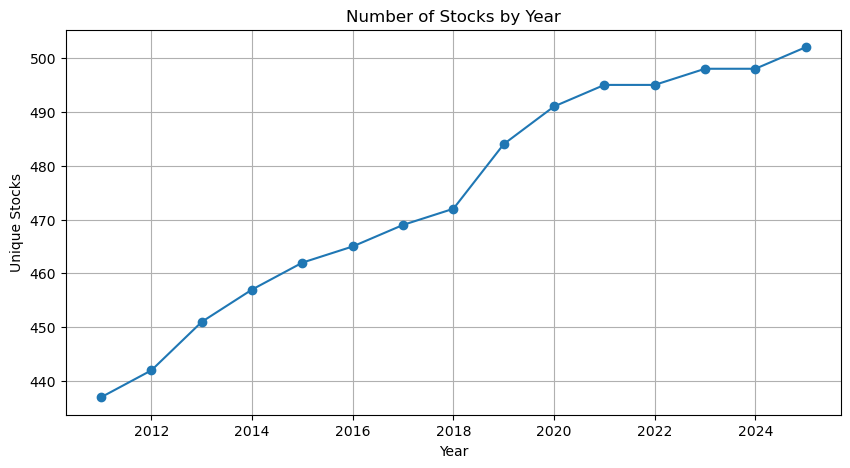

In [31]:
# =========================
# 16) STOCK COUNTS BY YEAR
# =========================

stocks_per_year = model_df.groupby("year")["ticker"].nunique().reset_index(name="n_stocks")
display(stocks_per_year)

plt.figure(figsize=(10, 5))
plt.plot(stocks_per_year["year"], stocks_per_year["n_stocks"], marker="o")
plt.title("Number of Stocks by Year")
plt.xlabel("Year")
plt.ylabel("Unique Stocks")
plt.grid(True)
plt.show()

In [33]:
# =========================
# 17) PREDICTOR SUMMARY
# =========================

predictor_cols = [
    c for c in model_df.columns
    if c not in ["security", "ticker", "year", "PX_LAST", "px_next_year", "return_next_year", "non_null_predictor_count"]
]

print("Usable predictors:")
print(predictor_cols)
print("\nCount:", len(predictor_cols))

Usable predictors:
['PROF_MARGIN', 'OPER_MARGIN', 'BS_TOT_ASSET', 'RETURN_ON_ASSET', 'TOT_DEBT_TO_TOT_EQY', 'RETURN_COM_EQY', 'CUR_MKT_CAP', 'EBITDA_MARGIN', 'VOLUME_AVG_30D', 'TURNOVER', 'VOLATILITY_30D', 'EARN_YLD', 'VOLATILITY_90D', 'VOLATILITY_360D', 'CURR_ENTP_VAL', 'PE_RATIO', 'CURRENT_EV_TO_T12M_EBITDA', 'GROSS_MARGIN', 'CF_FREE_CASH_FLOW_FIRM']

Count: 19


In [35]:
# =========================
# 18) SAVE OUTPUTS
# =========================

panel_df.to_csv("panel_dataset_raw_cleaned.csv", index=False)
model_df.to_csv("model_dataset_with_target.csv", index=False)

print("Saved files:")
print("- panel_dataset_raw_cleaned.csv")
print("- model_dataset_with_target.csv")
print("- missingness_report_before_filter.csv")
print("- missingness_report_after_filter.csv")

Saved files:
- panel_dataset_raw_cleaned.csv
- model_dataset_with_target.csv
- missingness_report_before_filter.csv
- missingness_report_after_filter.csv


In [37]:
# =========================
# 19) FINAL PREVIEW
# =========================

print("Final dataset shape:", model_df.shape)
display(model_df.head(20))
display(model_df.tail(20))

Final dataset shape: (7118, 26)


,security,ticker,year,PROF_MARGIN,OPER_MARGIN,BS_TOT_ASSET,RETURN_ON_ASSET,TOT_DEBT_TO_TOT_EQY,RETURN_COM_EQY,CUR_MKT_CAP,PX_LAST,EBITDA_MARGIN,VOLUME_AVG_30D,TURNOVER,VOLATILITY_30D,EARN_YLD,VOLATILITY_90D,VOLATILITY_360D,CURR_ENTP_VAL,PE_RATIO,CURRENT_EV_TO_T12M_EBITDA,GROSS_MARGIN,CF_FREE_CASH_FLOW_FIRM,px_next_year,return_next_year,non_null_predictor_count
0,A UN Equity,A,2011,12.5643,10.3968,9696.0,7.9039,114.0606,23.8577,12160.0137,24.9780,14.1073,8.690460e+05,7.928214e+09,23.034,6.3106,25.421,29.963,15451.2415,15.8464,20.1188,53.8207,691.8902,29.2757,0.172059,19
1,A UN Equity,A,2012,15.2986,16.1905,9057.0,10.7929,50.6256,26.8577,14244.4388,29.2757,20.0151,8.690460e+05,7.928214e+09,23.034,6.3106,25.421,29.963,15451.2415,15.8464,20.1188,53.3485,1156.3333,40.8958,0.396920,19
2,A UN Equity,A,2013,15.2986,16.1905,9057.0,10.7929,50.6256,26.8577,18976.1282,40.8958,20.0151,7.102285e+05,1.040959e+10,45.890,10.9916,60.069,44.833,10826.0137,9.0978,8.1767,53.3485,1156.3333,40.9400,0.001081,19
3,A UN Equity,A,2014,16.8125,16.3167,10536.0,11.7695,45.5545,24.2993,13728.0748,40.9400,20.7057,7.102285e+05,1.040959e+10,45.890,10.9916,60.069,44.833,10826.0137,9.0978,8.1767,52.5518,1156.3333,41.8100,0.021251,19
4,A UN Equity,A,2015,16.8125,16.3167,10536.0,11.7695,45.5545,24.2993,13888.0653,41.8100,20.7057,8.490908e+05,7.223454e+09,29.745,9.4589,24.671,43.744,14258.4388,10.5721,10.0412,52.5518,1156.3333,45.5600,0.089691,19
5,A UN Equity,A,2016,18.8495,9.9127,10686.0,6.9173,51.0304,14.0237,14658.8341,45.5600,19.4658,8.490908e+05,7.223454e+09,29.745,9.4589,24.671,43.744,14258.4388,10.5721,10.0412,48.9728,1039.1672,66.9700,0.469930,19
6,A UN Equity,A,2017,18.8495,9.9127,10686.0,6.9173,51.0304,14.0237,21632.5173,66.9700,19.4658,5.824393e+05,7.828999e+09,16.257,2.2128,22.696,24.109,19003.1282,45.1924,25.0701,48.9728,1039.1672,67.4600,0.007317,19
7,A UN Equity,A,2018,13.5623,10.3508,10815.0,5.1067,31.3537,10.3712,21488.2398,67.4600,19.8370,5.824393e+05,7.828999e+09,16.257,2.2128,22.696,24.109,19003.1282,45.1924,25.0701,48.8142,1039.1672,85.3100,0.264601,19
8,A UN Equity,A,2019,13.5623,10.3508,10815.0,5.1067,31.3537,10.3712,26461.7471,85.3100,19.8370,5.557143e+05,7.061739e+09,24.333,2.9557,22.813,22.430,13176.0748,33.8325,16.4086,48.8142,1039.1672,118.4900,0.388934,19
9,A UN Equity,A,2020,9.9307,12.9272,7479.0,4.3840,39.6882,8.4706,36358.6003,118.4900,19.1927,5.557143e+05,7.061739e+09,24.333,2.9557,22.813,22.430,13176.0748,33.8325,16.4086,50.5448,474.2250,159.6500,0.347371,19


,security,ticker,year,PROF_MARGIN,OPER_MARGIN,BS_TOT_ASSET,RETURN_ON_ASSET,TOT_DEBT_TO_TOT_EQY,RETURN_COM_EQY,CUR_MKT_CAP,PX_LAST,EBITDA_MARGIN,VOLUME_AVG_30D,TURNOVER,VOLATILITY_30D,EARN_YLD,VOLATILITY_90D,VOLATILITY_360D,CURR_ENTP_VAL,PE_RATIO,CURRENT_EV_TO_T12M_EBITDA,GROSS_MARGIN,CF_FREE_CASH_FLOW_FIRM,px_next_year,return_next_year,non_null_predictor_count
7262,ZBRA UW Equity,ZBRA,2020,0.4567,8.6513,4275.0,0.3817,267.0264,2.0910,20491.0943,384.33,15.7174,112208.9333,3.123484e+09,18.215,3.1398,23.206,28.276,7686.0290,31.8487,13.1385,45.9430,471.8523,595.20,0.548669,19
7263,ZBRA UW Equity,ZBRA,2021,9.9810,14.4618,4339.0,9.7748,119.1760,38.8197,31808.3754,595.20,18.6107,162613.0667,5.798195e+09,54.863,5.0793,41.690,36.771,10114.2947,19.6879,12.8845,46.9654,794.1126,256.41,-0.569204,19
7264,ZBRA UW Equity,ZBRA,2022,12.1293,15.4292,4711.0,12.0221,76.4546,34.2785,13238.3965,256.41,20.1561,350012.0000,1.119000e+10,19.190,4.2057,30.841,41.114,15149.7023,23.7773,16.7585,46.8227,704.9632,273.33,0.065988,19
7265,ZBRA UW Equity,ZBRA,2023,11.3309,14.6358,5375.0,9.9941,65.4851,25.3076,14038.1206,273.33,18.7050,163298.3000,1.067428e+10,25.699,2.7470,37.421,45.977,21727.0943,36.4040,26.1143,45.0315,963.4000,386.22,0.413017,19
7266,ZBRA UW Equity,ZBRA,2024,14.8747,17.3983,6215.0,14.4435,38.3713,32.6443,19921.2384,386.22,21.4146,105000.5000,1.399612e+10,31.476,2.7172,29.046,30.324,32621.3754,36.8026,27.0717,46.7034,1014.3233,242.82,-0.371291,19
7267,ZBRA UW Equity,ZBRA,2025,14.8747,17.3983,6215.0,14.4435,38.3713,32.6443,12301.3200,242.82,21.4146,186553.6000,1.468926e+10,33.252,6.3044,54.111,42.675,15332.3965,15.8620,19.6317,46.7034,1014.3233,NaN,NaN,19
7269,ZTS UN Equity,ZTS,2012,5.7879,11.2922,5711.0,4.4566,15.3908,6.9366,NaN,NaN,16.1351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.9733,384.6599,32.69,NaN,9
7270,ZTS UN Equity,ZTS,2013,10.0554,16.0286,6262.0,7.2831,14.4024,11.2574,16345.2235,32.69,20.6411,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.9530,347.0366,43.03,0.316305,10
7271,ZTS UN Equity,ZTS,2014,11.0502,17.4085,6558.0,7.8627,380.1455,20.2980,21572.0074,43.03,21.9908,751742.0000,8.086561e+09,11.169,4.3377,16.999,22.678,19414.2235,23.0537,19.3562,63.4071,579.3754,47.92,0.113642,19
7272,ZTS UN Equity,ZTS,2015,12.1839,19.7283,6588.0,8.8696,271.5782,51.7992,23860.3490,47.92,23.9916,997729.2333,7.517773e+09,25.751,3.5698,26.626,20.319,24347.0074,28.0129,21.2082,64.1170,529.7549,53.53,0.117070,19


In [39]:
# =========================
# 20) 2025 SNAPSHOT FOR 2026 PORTFOLIO
# =========================

portfolio_2025_df = model_df[model_df["year"] == 2025].copy()

print("2025 rows:", len(portfolio_2025_df))
print("2025 unique tickers:", portfolio_2025_df["ticker"].nunique())

display(portfolio_2025_df.head())

portfolio_2025_df.to_csv("portfolio_input_2025_for_2026.csv", index=False)

2025 rows: 502
2025 unique tickers: 502


,security,ticker,year,PROF_MARGIN,OPER_MARGIN,BS_TOT_ASSET,RETURN_ON_ASSET,TOT_DEBT_TO_TOT_EQY,RETURN_COM_EQY,CUR_MKT_CAP,PX_LAST,EBITDA_MARGIN,VOLUME_AVG_30D,TURNOVER,VOLATILITY_30D,EARN_YLD,VOLATILITY_90D,VOLATILITY_360D,CURR_ENTP_VAL,PE_RATIO,CURRENT_EV_TO_T12M_EBITDA,GROSS_MARGIN,CF_FREE_CASH_FLOW_FIRM,px_next_year,return_next_year,non_null_predictor_count
14,A UN Equity,A,2025,15.2952,18.8059,8426.0,8.4340,41.5926,15.0760,3.857569e+04,136.07,23.5465,6.405560e+05,7.910953e+09,19.085,3.1610,14.286,18.632,20969.5173,31.6353,19.9141,53.8685,780.2927,NaN,NaN,19
29,AAPL UW Equity,AAPL,2025,21.0924,26.7604,375319.0,13.8739,86.2981,36.8675,4.017099e+06,271.86,31.1913,2.996568e+07,2.717278e+11,16.387,5.3882,17.418,17.861,707667.4869,18.5589,9.8973,38.4699,53526.5531,NaN,NaN,19
44,ABBV UN Equity,ABBV,2025,20.5385,31.8949,146529.0,7.7699,502.7209,80.5224,4.038297e+05,228.49,47.4598,1.787624e+06,7.092521e+10,15.408,6.5431,23.845,22.472,340816.1349,15.2833,12.7241,68.9556,24144.3789,NaN,NaN,19
52,ABNB UW Equity,ABNB,2025,22.5384,21.4549,16038.0,26.1265,28.2180,69.8288,8.354241e+04,135.72,23.3361,1.767990e+06,6.404280e+10,32.109,5.3154,38.269,46.310,80511.3574,18.8132,49.6984,82.1526,3427.8416,NaN,NaN,19
67,ABT UN Equity,ABT,2025,16.4156,19.5589,75196.0,9.5720,53.4394,20.6194,2.178633e+05,125.29,28.6059,1.650545e+06,5.030691e+10,21.234,3.9688,27.952,24.766,199213.9650,25.1963,16.6233,56.9658,9106.9993,NaN,NaN,19


In [41]:
# =========================
# 1) LOAD DAILY SENTIMENT
# =========================

import pandas as pd
import numpy as np

sentiment_file = "/Users/williamferris/Desktop/Data400MP/Sentiment2.xlsx"

sent_raw = pd.read_excel(sentiment_file, sheet_name="Sentiment")

print("Raw shape:", sent_raw.shape)
display(sent_raw.head())

Raw shape: (1301, 504)


,Unnamed: 0,A UN Equity,AAPL UW Equity,ABBV UN Equity,ABNB UW Equity,ABT UN Equity,ACGL UW Equity,ACN UN Equity,ADBE UW Equity,ADI UW Equity,ADM UN Equity,ADP UW Equity,ADSK UW Equity,AEE UN Equity,AEP UW Equity,AES UN Equity,AFL UN Equity,AIG UN Equity,AIZ UN Equity,AJG UN Equity,AKAM UW Equity,ALB UN Equity,ALGN UW Equity,ALL UN Equity,ALLE UN Equity,AMAT UW Equity,AMCR UN Equity,AMD UW Equity,AME UN Equity,AMGN UW Equity,AMP UN Equity,AMT UN Equity,AMZN UW Equity,ANET UN Equity,AON UN Equity,AOS UN Equity,APA UW Equity,APD UN Equity,APH UN Equity,APO UN Equity,APP UW Equity,APTV UN Equity,ARE UN Equity,ARES UN Equity,ATO UN Equity,AVB UN Equity,AVGO UW Equity,AVY UN Equity,AWK UN Equity,AXON UW Equity,AXP UN Equity,AZO UN Equity,BA UN Equity,BAC UN Equity,BALL UN Equity,BAX UN Equity,BBY UN Equity,BDX UN Equity,BEN UN Equity,BF/B UN Equity,BG UN Equity,BIIB UW Equity,BK UN Equity,BKNG UW Equity,BKR UW Equity,BLDR UN Equity,BLK UN Equity,BMY UN Equity,BR UN Equity,BRK/B UN Equity,BRO UN Equity,BSX UN Equity,BX UN Equity,BXP UN Equity,C UN Equity,CAG UN Equity,CAH UN Equity,CARR UN Equity,CASY UW Equity,CAT UN Equity,CB UN Equity,CBOE UF Equity,CBRE UN Equity,CCI UN Equity,CCL UN Equity,CDNS UW Equity,CDW UW Equity,CEG UW Equity,CF UN Equity,CFG UN Equity,CHD UN Equity,CHRW UW Equity,CHTR UW Equity,CI UN Equity,CIEN UN Equity,CINF UW Equity,CL UN Equity,CLX UN Equity,CMCSA UW Equity,CME UW Equity,...,SCHW UN Equity,SHW UN Equity,SJM UN Equity,SLB UN Equity,SMCI UW Equity,SNA UN Equity,SNDK UW Equity,SNPS UW Equity,SO UN Equity,SOLV UN Equity,SPG UN Equity,SPGI UN Equity,SRE UN Equity,STE UN Equity,STLD UW Equity,STT UN Equity,STX UW Equity,STZ UN Equity,SW UN Equity,SWK UN Equity,SWKS UW Equity,SYF UN Equity,SYK UN Equity,SYY UN Equity,T UN Equity,TAP UN Equity,TDG UN Equity,TDY UN Equity,TECH UW Equity,TEL UN Equity,TER UW Equity,TFC UN Equity,TGT UN Equity,TJX UN Equity,TKO UN Equity,TMO UN Equity,TMUS UW Equity,TPL UN Equity,TPR UN Equity,TRGP UN Equity,TRMB UW Equity,TROW UW Equity,TRV UN Equity,TSCO UW Equity,TSLA UW Equity,TSN UN Equity,TT UN Equity,TTD UQ Equity,TTWO UW Equity,TXN UW Equity,TXT UN Equity,TYL UN Equity,UAL UW Equity,UBER UN Equity,UDR UN Equity,UHS UN Equity,ULTA UW Equity,UNH UN Equity,UNP UN Equity,UPS UN Equity,URI UN Equity,USB UN Equity,V UN Equity,VICI UN Equity,VLO UN Equity,VLTO UN Equity,VMC UN Equity,VRSK UW Equity,VRSN UW Equity,VRT UN Equity,VRTX UW Equity,VST UN Equity,VTR UN Equity,VTRS UW Equity,VZ UN Equity,WAB UN Equity,WAT UN Equity,WBD UW Equity,WDAY UW Equity,WDC UW Equity,WEC UN Equity,WELL UN Equity,WFC UN Equity,WM UN Equity,WMB UN Equity,WMT UW Equity,WRB UN Equity,WSM UN Equity,WST UN Equity,WTW UW Equity,WY UN Equity,WYNN UW Equity,XEL UW Equity,XOM UN Equity,XYL UN Equity,XYZ UN Equity,YUM UN Equity,ZBH UN Equity,ZBRA UW Equity,ZTS UN Equity
0,DATES,news_sentiment_daily_avg(dates=range(2022-09-2...,news_sentiment_daily_avg(dates=range(2022-09-2...,news_sentiment_daily_avg(dates=range(2022-09-2...,news_sentiment_daily_avg(dates=range(2022-09-2...,news_sentiment_daily_avg(dates=range(2022-09-2...,news_sentiment_daily_avg(dates=range(2022-09-2...,news_sentiment_daily_avg(dates=range(2022-09-2...,news_sentiment_daily_avg(dates=range(2022-09-2...,news_sentiment_daily_avg(dates=range(2022-09-2...,news_sentiment_daily_avg(dates=range(2022-09-2...,news_sentiment_daily_avg(dates=range(2022-09-2...,news_sentiment_daily_avg(dates=range(2022-09-2...,news_sentiment_daily_avg(dates=range(2022-09-2...,news_sentiment_daily_avg(dates=range(2022-09-2...,news_sentiment_daily_avg(dates=range(2022-09-2...,news_sentiment_daily_avg(dates=range(2022-09-2...,news_sentiment_daily_avg(dates=range(2022-09-2...,news_sentiment_daily_avg(dates=range(2022-09-2...,news_sentiment_daily_avg(dates=range(2022-09-2...,news_sentiment_daily_avg(dates=range(2022-09-2...,news_sentiment_daily_avg(dates=range(2022-09-2...,news_sentiment_daily_avg(dates=range(2022-09-2...,news_sentiment_daily_avg(dates=range(2022-09-2...

In [42]:
# =========================
# 2) CLEAN DATE COLUMN
# =========================

# first column contains dates
date_col = sent_raw.columns[0]

sent_raw = sent_raw.rename(columns={date_col: "date"})

# convert date column; the first row ("DATES") will become NaT
sent_raw["date"] = pd.to_datetime(sent_raw["date"], errors="coerce")

# keep only real dated rows
sent_raw = sent_raw[sent_raw["date"].notna()].copy()

print("Shape after dropping non-date rows:", sent_raw.shape)
print("Date range:", sent_raw["date"].min(), "to", sent_raw["date"].max())
display(sent_raw.head())

Shape after dropping non-date rows: (1300, 504)
Date range: 2022-09-26 00:00:00 to 2026-04-17 00:00:00


,date,A UN Equity,AAPL UW Equity,ABBV UN Equity,ABNB UW Equity,ABT UN Equity,ACGL UW Equity,ACN UN Equity,ADBE UW Equity,ADI UW Equity,ADM UN Equity,ADP UW Equity,ADSK UW Equity,AEE UN Equity,AEP UW Equity,AES UN Equity,AFL UN Equity,AIG UN Equity,AIZ UN Equity,AJG UN Equity,AKAM UW Equity,ALB UN Equity,ALGN UW Equity,ALL UN Equity,ALLE UN Equity,AMAT UW Equity,AMCR UN Equity,AMD UW Equity,AME UN Equity,AMGN UW Equity,AMP UN Equity,AMT UN Equity,AMZN UW Equity,ANET UN Equity,AON UN Equity,AOS UN Equity,APA UW Equity,APD UN Equity,APH UN Equity,APO UN Equity,APP UW Equity,APTV UN Equity,ARE UN Equity,ARES UN Equity,ATO UN Equity,AVB UN Equity,AVGO UW Equity,AVY UN Equity,AWK UN Equity,AXON UW Equity,AXP UN Equity,AZO UN Equity,BA UN Equity,BAC UN Equity,BALL UN Equity,BAX UN Equity,BBY UN Equity,BDX UN Equity,BEN UN Equity,BF/B UN Equity,BG UN Equity,BIIB UW Equity,BK UN Equity,BKNG UW Equity,BKR UW Equity,BLDR UN Equity,BLK UN Equity,BMY UN Equity,BR UN Equity,BRK/B UN Equity,BRO UN Equity,BSX UN Equity,BX UN Equity,BXP UN Equity,C UN Equity,CAG UN Equity,CAH UN Equity,CARR UN Equity,CASY UW Equity,CAT UN Equity,CB UN Equity,CBOE UF Equity,CBRE UN Equity,CCI UN Equity,CCL UN Equity,CDNS UW Equity,CDW UW Equity,CEG UW Equity,CF UN Equity,CFG UN Equity,CHD UN Equity,CHRW UW Equity,CHTR UW Equity,CI UN Equity,CIEN UN Equity,CINF UW Equity,CL UN Equity,CLX UN Equity,CMCSA UW Equity,CME UW Equity,...,SCHW UN Equity,SHW UN Equity,SJM UN Equity,SLB UN Equity,SMCI UW Equity,SNA UN Equity,SNDK UW Equity,SNPS UW Equity,SO UN Equity,SOLV UN Equity,SPG UN Equity,SPGI UN Equity,SRE UN Equity,STE UN Equity,STLD UW Equity,STT UN Equity,STX UW Equity,STZ UN Equity,SW UN Equity,SWK UN Equity,SWKS UW Equity,SYF UN Equity,SYK UN Equity,SYY UN Equity,T UN Equity,TAP UN Equity,TDG UN Equity,TDY UN Equity,TECH UW Equity,TEL UN Equity,TER UW Equity,TFC UN Equity,TGT UN Equity,TJX UN Equity,TKO UN Equity,TMO UN Equity,TMUS UW Equity,TPL UN Equity,TPR UN Equity,TRGP UN Equity,TRMB UW Equity,TROW UW Equity,TRV UN Equity,TSCO UW Equity,TSLA UW Equity,TSN UN Equity,TT UN Equity,TTD UQ Equity,TTWO UW Equity,TXN UW Equity,TXT UN Equity,TYL UN Equity,UAL UW Equity,UBER UN Equity,UDR UN Equity,UHS UN Equity,ULTA UW Equity,UNH UN Equity,UNP UN Equity,UPS UN Equity,URI UN Equity,USB UN Equity,V UN Equity,VICI UN Equity,VLO UN Equity,VLTO UN Equity,VMC UN Equity,VRSK UW Equity,VRSN UW Equity,VRT UN Equity,VRTX UW Equity,VST UN Equity,VTR UN Equity,VTRS UW Equity,VZ UN Equity,WAB UN Equity,WAT UN Equity,WBD UW Equity,WDAY UW Equity,WDC UW Equity,WEC UN Equity,WELL UN Equity,WFC UN Equity,WM UN Equity,WMB UN Equity,WMT UW Equity,WRB UN Equity,WSM UN Equity,WST UN Equity,WTW UW Equity,WY UN Equity,WYNN UW Equity,XEL UW Equity,XOM UN Equity,XYL UN Equity,XYZ UN Equity,YUM UN Equity,ZBH UN Equity,ZBRA UW Equity,ZTS UN Equity
1,2022-09-26,NaN,-0.0003,0,0,0,NaN,0,0.036,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0,NaN,NaN,-0.0113,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0,0,NaN,NaN,-0.0206,NaN,-0.1425,0,0,NaN,0,0,0,NaN,NaN,0,NaN,0,0,NaN,0,0,NaN,0,NaN,0,-0.0517,0,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0,NaN,-0.0955,0,NaN,NaN,0,0,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,0,0,-0.0012,NaN,NaN,NaN,0,NaN,NaN,0,0,NaN,NaN,NaN,-0.062,0,NaN,0,NaN,NaN,0,0,-0.0036,NaN,NaN,NaN,NaN,0,NaN,NaN,0,-0.058,NaN,NaN,NaN,NaN,0,-0.188,NaN,0,0,NaN,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,-0.6321,0,0,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,-0.0019,NaN,NaN,NaN,0,NaN,0.6877,0,0,NaN,0,0,NaN,NaN,0
2,2022-09-27,-0.8647,0.0013,-0.5866,0,-0.7671,-0.9933,-0.1136,-0.1819,-0.9302,-0.4205,-0.9515,-0.0544,-0.6321,-0.1849,-0.0931,-0.9933,-0.4167,-0.2152,-0.8877,-0.8647,-0.4748,-0.6321,-0.487,-0.6321,-0.9502,-0.6321,-0.0006,-0.8647,-0.9322,-0.8647,-0.1317,0.007,-0.039,-0.0048,-0.6321,-0.6896,-0.9469,-0.6321,0.0309,NaN,-0.6321,-0.8647,0,-0.9933,-0.8492,-0.0841,-0.6321,-0.0404,0,-0.0957,-0.9107,-0.4102,-0.3447,-0.0109,-0.4801,-0.

In [43]:
# =========================
# 3) WIDE TO LONG
# =========================

sent_long = sent_raw.melt(
    id_vars="date",
    var_name="security",
    value_name="daily_sentiment"
)

# numeric conversion
sent_long["daily_sentiment"] = pd.to_numeric(sent_long["daily_sentiment"], errors="coerce")

print("Long shape:", sent_long.shape)
display(sent_long.head())

Long shape: (653900, 3)


,date,security,daily_sentiment
0,2022-09-26,A UN Equity,NaN
1,2022-09-27,A UN Equity,-0.8647
2,2022-09-28,A UN Equity,-0.8647
3,2022-09-29,A UN Equity,0.9817
4,2022-09-30,A UN Equity,-0.0746


In [44]:
# =========================
# 4) CLEAN TICKER
# =========================

def clean_ticker(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x == "":
        return np.nan
    return x.split()[0]

sent_long["ticker"] = sent_long["security"].apply(clean_ticker)

# add calendar year
sent_long["year"] = sent_long["date"].dt.year

display(sent_long.head())

,date,security,daily_sentiment,ticker,year
0,2022-09-26,A UN Equity,NaN,A,2022
1,2022-09-27,A UN Equity,-0.8647,A,2022
2,2022-09-28,A UN Equity,-0.8647,A,2022
3,2022-09-29,A UN Equity,0.9817,A,2022
4,2022-09-30,A UN Equity,-0.0746,A,2022


In [45]:
# =========================
# 5) YEARLY AGGREGATION
# =========================

sent_yearly = (
    sent_long
    .groupby(["ticker", "year"], as_index=False)
    .agg(
        sentiment_mean=("daily_sentiment", "mean"),
        sentiment_std=("daily_sentiment", "std"),
        sentiment_median=("daily_sentiment", "median"),
        sentiment_min=("daily_sentiment", "min"),
        sentiment_max=("daily_sentiment", "max"),
        sentiment_obs=("daily_sentiment", "count")
    )
)

print("Yearly sentiment shape:", sent_yearly.shape)
display(sent_yearly.head(20))

Yearly sentiment shape: (2515, 8)


,ticker,year,sentiment_mean,sentiment_std,sentiment_median,sentiment_min,sentiment_max,sentiment_obs
0,A,2022,0.004640,0.524032,0.00000,-0.9656,0.9817,55
1,A,2023,-0.083124,0.467874,-0.05110,-0.9933,0.9933,208
2,A,2024,-0.052070,0.283703,-0.04440,-0.5864,0.5116,223
3,A,2025,-0.002384,0.196067,0.00000,-0.4502,0.6266,204
4,A,2026,-0.006993,0.197676,0.00000,-0.3723,0.3553,56
5,AAPL,2022,-0.022780,0.043537,-0.00560,-0.1893,0.0267,70
6,AAPL,2023,-0.015877,0.063326,-0.00170,-0.5035,0.0763,260
7,AAPL,2024,-0.023019,0.094809,-0.00220,-0.8754,0.2493,262
8,AAPL,2025,-0.010228,0.087736,-0.00310,-0.3897,0.6279,261
9,AAPL,2026,0.003833,0.058269,0.00020,-0.0857,0.4875,76


In [46]:
# =========================
# 6) COVERAGE CHECK
# =========================

coverage = sent_yearly.groupby("year").agg(
    n_tickers=("ticker", "nunique"),
    avg_obs_per_ticker=("sentiment_obs", "mean"),
    median_obs_per_ticker=("sentiment_obs", "median")
).reset_index()

display(coverage)

,year,n_tickers,avg_obs_per_ticker,median_obs_per_ticker
0,2022,503,58.208748,60.0
1,2023,503,216.616302,223.0
2,2024,503,219.343936,225.0
3,2025,503,209.769384,214.0
4,2026,503,62.622266,64.0


In [47]:
# =========================
# 7) FILTER TO USABLE YEARS
# =========================

sent_yearly_filtered = sent_yearly[sent_yearly["year"].between(2023, 2025)].copy()

print("Filtered yearly sentiment shape:", sent_yearly_filtered.shape)
display(sent_yearly_filtered.head())

Filtered yearly sentiment shape: (1509, 8)


,ticker,year,sentiment_mean,sentiment_std,sentiment_median,sentiment_min,sentiment_max,sentiment_obs
1,A,2023,-0.083124,0.467874,-0.0511,-0.9933,0.9933,208
2,A,2024,-0.052070,0.283703,-0.0444,-0.5864,0.5116,223
3,A,2025,-0.002384,0.196067,0.0000,-0.4502,0.6266,204
6,AAPL,2023,-0.015877,0.063326,-0.0017,-0.5035,0.0763,260
7,AAPL,2024,-0.023019,0.094809,-0.0022,-0.8754,0.2493,262


In [51]:
# =========================
# 8) MERGE INTO MODEL_DF
# =========================

model_df = model_df.merge(
    sent_yearly_filtered,
    on=["ticker", "year"],
    how="left"
)

print("model_df shape after sentiment merge:", model_df.shape)

# coverage check inside model_df
print("\nMissing sentiment_mean values:", model_df["sentiment_mean"].isna().sum())
print("Non-missing sentiment_mean values:", model_df["sentiment_mean"].notna().sum())

display(model_df.head())

model_df shape after sentiment merge: (7118, 32)

Missing sentiment_mean values: 5625
Non-missing sentiment_mean values: 1493


,security,ticker,year,PROF_MARGIN,OPER_MARGIN,BS_TOT_ASSET,RETURN_ON_ASSET,TOT_DEBT_TO_TOT_EQY,RETURN_COM_EQY,CUR_MKT_CAP,PX_LAST,EBITDA_MARGIN,VOLUME_AVG_30D,TURNOVER,VOLATILITY_30D,EARN_YLD,VOLATILITY_90D,VOLATILITY_360D,CURR_ENTP_VAL,PE_RATIO,CURRENT_EV_TO_T12M_EBITDA,GROSS_MARGIN,CF_FREE_CASH_FLOW_FIRM,px_next_year,return_next_year,non_null_predictor_count,sentiment_mean,sentiment_std,sentiment_median,sentiment_min,sentiment_max,sentiment_obs
0,A UN Equity,A,2011,12.5643,10.3968,9696.0,7.9039,114.0606,23.8577,12160.0137,24.9780,14.1073,869046.0333,7.928214e+09,23.034,6.3106,25.421,29.963,15451.2415,15.8464,20.1188,53.8207,691.8902,29.2757,0.172059,19,NaN,NaN,NaN,NaN,NaN,NaN
1,A UN Equity,A,2012,15.2986,16.1905,9057.0,10.7929,50.6256,26.8577,14244.4388,29.2757,20.0151,869046.0333,7.928214e+09,23.034,6.3106,25.421,29.963,15451.2415,15.8464,20.1188,53.3485,1156.3333,40.8958,0.396920,19,NaN,NaN,NaN,NaN,NaN,NaN
2,A UN Equity,A,2013,15.2986,16.1905,9057.0,10.7929,50.6256,26.8577,18976.1282,40.8958,20.0151,710228.5000,1.040959e+10,45.890,10.9916,60.069,44.833,10826.0137,9.0978,8.1767,53.3485,1156.3333,40.9400,0.001081,19,NaN,NaN,NaN,NaN,NaN,NaN
3,A UN Equity,A,2014,16.8125,16.3167,10536.0,11.7695,45.5545,24.2993,13728.0748,40.9400,20.7057,710228.5000,1.040959e+10,45.890,10.9916,60.069,44.833,10826.0137,9.0978,8.1767,52.5518,1156.3333,41.8100,0.021251,19,NaN,NaN,NaN,NaN,NaN,NaN
4,A UN Equity,A,2015,16.8125,16.3167,10536.0,11.7695,45.5545,24.2993,13888.0653,41.8100,20.7057,849090.8000,7.223454e+09,29.745,9.4589,24.671,43.744,14258.4388,10.5721,10.0412,52.5518,1156.3333,45.5600,0.089691,19,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
# =========================
# 9) SENTIMENT COVERAGE CHECKS
# =========================

print("Coverage by year in model_df:")
display(
    model_df.groupby("year")["sentiment_mean"]
    .apply(lambda x: x.notna().mean())
    .reset_index(name="pct_with_sentiment")
)

print("\n2025 portfolio coverage:")
portfolio_2025_check = model_df[model_df["year"] == 2025].copy()

print("2025 rows:", len(portfolio_2025_check))
print("2025 rows with sentiment:", portfolio_2025_check["sentiment_mean"].notna().sum())

display(
    portfolio_2025_check[["ticker", "year", "sentiment_mean", "sentiment_std", "sentiment_obs"]]
    .head(20)
)

Coverage by year in model_df:


,year,pct_with_sentiment
0,2011,0.000000
1,2012,0.000000
2,2013,0.000000
3,2014,0.000000
4,2015,0.000000
5,2016,0.000000
6,2017,0.000000
7,2018,0.000000
8,2019,0.000000
9,2020,0.000000



2025 portfolio coverage:
2025 rows: 502
2025 rows with sentiment: 501


,ticker,year,sentiment_mean,sentiment_std,sentiment_obs
14,A,2025,-0.002384,0.196067,204.0
29,AAPL,2025,-0.010228,0.087736,261.0
43,ABBV,2025,0.003210,0.187107,260.0
50,ABNB,2025,-0.003496,0.068732,261.0
65,ABT,2025,-0.000538,0.221817,229.0
80,ACGL,2025,0.016135,0.085623,182.0
95,ACN,2025,-0.020178,0.274732,251.0
110,ADBE,2025,-0.018015,0.173890,238.0
125,ADI,2025,0.021368,0.436892,233.0
140,ADM,2025,-0.052957,0.212940,212.0


In [59]:
# =========================
# 10) SAVE UPDATED DATASET
# =========================

sent_yearly_filtered.to_csv("yearly_sentiment_aggregated.csv", index=False)
model_df.to_csv("model_dataset_with_sentiment.csv", index=False)

print("Saved:")
print("- yearly_sentiment_aggregated.csv")
print("- model_dataset_with_sentiment.csv")

Saved:
- yearly_sentiment_aggregated.csv
- model_dataset_with_sentiment.csv


In [61]:
# =========================
# 1) LOAD INDUSTRY / SECTOR DATA
# =========================

sector_file = "/Users/williamferris/Desktop/Data400MP/bloomberg_ratios.xlsx"

industry_raw = pd.read_excel(sector_file, sheet_name="Industry")

print("Shape:", industry_raw.shape)
display(industry_raw.head())
print(industry_raw.columns.tolist())

Shape: (2436, 6)


,Ticker,Name,GICS Sector,GICS Ind Grp Name,Rev - 1 Yr Gr:2024C,Curr Ratio:2024C
0,FLWS US Equity,1-800-FLOWERS.COM INC-CL A,Consumer Discretionary,Consumer Discretionary Distribution & Retail,-9.2391,1.6932
1,TXG US Equity,10X GENOMICS INC-CLASS A,Health Care,"Pharmaceuticals, Biotechnology & Life Sciences",-1.2836,4.9679
2,SRCE US Equity,1ST SOURCE CORP,Financials,Banks,12.3725,
3,DDD US Equity,3D SYSTEMS CORP,Industrials,Capital Goods,-9.824,3.083
4,MMM US Equity,3M CO,Industrials,Capital Goods,-24.8034,1.4112


['Ticker', 'Name', 'GICS Sector', 'GICS Ind Grp Name', 'Rev - 1 Yr Gr:2024C', 'Curr Ratio:2024C']


In [63]:
# =========================
# 2) KEEP NEEDED COLUMNS
# =========================

sector_df = industry_raw[["Ticker", "GICS Sector"]].copy()

sector_df = sector_df.rename(columns={
    "Ticker": "security_sector_raw",
    "GICS Sector": "sector"
})

display(sector_df.head())

,security_sector_raw,sector
0,FLWS US Equity,Consumer Discretionary
1,TXG US Equity,Health Care
2,SRCE US Equity,Financials
3,DDD US Equity,Industrials
4,MMM US Equity,Industrials


In [65]:
# =========================
# 3) CLEAN TICKER
# =========================

def clean_ticker(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x == "":
        return np.nan
    return x.split()[0]

sector_df["ticker"] = sector_df["security_sector_raw"].apply(clean_ticker)

display(sector_df.head())

,security_sector_raw,sector,ticker
0,FLWS US Equity,Consumer Discretionary,FLWS
1,TXG US Equity,Health Care,TXG
2,SRCE US Equity,Financials,SRCE
3,DDD US Equity,Industrials,DDD
4,MMM US Equity,Industrials,MMM


In [67]:
# =========================
# 4) DROP BAD ROWS
# =========================

sector_df = sector_df[sector_df["ticker"].notna()].copy()
sector_df = sector_df[sector_df["sector"].notna()].copy()

sector_df = sector_df[["ticker", "sector"]].drop_duplicates()

print("Rows after cleaning:", len(sector_df))
print("Unique tickers:", sector_df["ticker"].nunique())
print("Unique sectors:", sector_df["sector"].nunique())

display(sector_df.head(20))

Rows after cleaning: 2436
Unique tickers: 2436
Unique sectors: 11


,ticker,sector
0,FLWS,Consumer Discretionary
1,TXG,Health Care
2,SRCE,Financials
3,DDD,Industrials
4,MMM,Industrials
5,FDMT,Health Care
6,EGHT,Information Technology
7,MASS,Information Technology
8,ATEN,Information Technology
9,AIR,Industrials


In [69]:
# =========================
# 5) CHECK FOR CONFLICTS
# =========================

sector_conflicts = (
    sector_df.groupby("ticker")["sector"]
    .nunique()
    .reset_index(name="n_sectors")
)

sector_conflicts = sector_conflicts[sector_conflicts["n_sectors"] > 1]

print("Tickers with conflicting sectors:", len(sector_conflicts))
display(sector_conflicts.head())

Tickers with conflicting sectors: 0


,ticker,n_sectors


In [71]:
sector_df = sector_df.drop_duplicates(subset=["ticker"], keep="first")

In [73]:
# =========================
# 6) MERGE INTO MODEL_DF
# =========================

model_df = model_df.merge(
    sector_df,
    on="ticker",
    how="left"
)

print("model_df shape after sector merge:", model_df.shape)
print("Missing sector values:", model_df["sector"].isna().sum())

display(model_df.head())

model_df shape after sector merge: (7118, 33)
Missing sector values: 31


,security,ticker,year,PROF_MARGIN,OPER_MARGIN,BS_TOT_ASSET,RETURN_ON_ASSET,TOT_DEBT_TO_TOT_EQY,RETURN_COM_EQY,CUR_MKT_CAP,PX_LAST,EBITDA_MARGIN,VOLUME_AVG_30D,TURNOVER,VOLATILITY_30D,EARN_YLD,VOLATILITY_90D,VOLATILITY_360D,CURR_ENTP_VAL,PE_RATIO,CURRENT_EV_TO_T12M_EBITDA,GROSS_MARGIN,CF_FREE_CASH_FLOW_FIRM,px_next_year,return_next_year,non_null_predictor_count,sentiment_mean,sentiment_std,sentiment_median,sentiment_min,sentiment_max,sentiment_obs,sector
0,A UN Equity,A,2011,12.5643,10.3968,9696.0,7.9039,114.0606,23.8577,12160.0137,24.9780,14.1073,869046.0333,7.928214e+09,23.034,6.3106,25.421,29.963,15451.2415,15.8464,20.1188,53.8207,691.8902,29.2757,0.172059,19,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
1,A UN Equity,A,2012,15.2986,16.1905,9057.0,10.7929,50.6256,26.8577,14244.4388,29.2757,20.0151,869046.0333,7.928214e+09,23.034,6.3106,25.421,29.963,15451.2415,15.8464,20.1188,53.3485,1156.3333,40.8958,0.396920,19,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2,A UN Equity,A,2013,15.2986,16.1905,9057.0,10.7929,50.6256,26.8577,18976.1282,40.8958,20.0151,710228.5000,1.040959e+10,45.890,10.9916,60.069,44.833,10826.0137,9.0978,8.1767,53.3485,1156.3333,40.9400,0.001081,19,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
3,A UN Equity,A,2014,16.8125,16.3167,10536.0,11.7695,45.5545,24.2993,13728.0748,40.9400,20.7057,710228.5000,1.040959e+10,45.890,10.9916,60.069,44.833,10826.0137,9.0978,8.1767,52.5518,1156.3333,41.8100,0.021251,19,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
4,A UN Equity,A,2015,16.8125,16.3167,10536.0,11.7695,45.5545,24.2993,13888.0653,41.8100,20.7057,849090.8000,7.223454e+09,29.745,9.4589,24.671,43.744,14258.4388,10.5721,10.0412,52.5518,1156.3333,45.5600,0.089691,19,NaN,NaN,NaN,NaN,NaN,NaN,Health Care


In [75]:
# =========================
# 7) SECTOR COVERAGE BY YEAR
# =========================

sector_coverage = (
    model_df.groupby("year")["sector"]
    .apply(lambda x: x.notna().mean())
    .reset_index(name="pct_with_sector")
)

display(sector_coverage)

,year,pct_with_sector
0,2011,0.997712
1,2012,0.997738
2,2013,0.997783
3,2014,0.997812
4,2015,0.997835
5,2016,0.995699
6,2017,0.995736
7,2018,0.995763
8,2019,0.995868
9,2020,0.993890


In [77]:
# =========================
# 8) 2025 SECTOR DISTRIBUTION
# =========================

portfolio_2025 = model_df[model_df["year"] == 2025].copy()

print("2025 rows:", len(portfolio_2025))
print("2025 rows with sector:", portfolio_2025["sector"].notna().sum())

print("\nSector counts in 2025:")
print(portfolio_2025["sector"].value_counts())

display(portfolio_2025[["ticker", "sector"]].head(20))

2025 rows: 502
2025 rows with sector: 499

Sector counts in 2025:
sector
Industrials               78
Financials                76
Information Technology    70
Health Care               59
Consumer Discretionary    48
Consumer Staples          35
Utilities                 31
Real Estate               31
Materials                 26
Communication Services    23
Energy                    22
Name: count, dtype: int64


,ticker,sector
14,A,Health Care
29,AAPL,Information Technology
43,ABBV,Health Care
50,ABNB,Consumer Discretionary
65,ABT,Health Care
80,ACGL,Financials
95,ACN,Information Technology
110,ADBE,Information Technology
125,ADI,Information Technology
140,ADM,Consumer Staples


In [79]:
# =========================
# 9) SAVE UPDATED DATASET
# =========================

model_df.to_csv("model_dataset_with_sentiment_and_sector.csv", index=False)

print("Saved: model_dataset_with_sentiment_and_sector.csv")

Saved: model_dataset_with_sentiment_and_sector.csv


In [81]:
print("Final shape:", model_df.shape)

print("\nMissing values summary:")
print(model_df.isna().mean().sort_values(ascending=False).head(10))

print("\nYears:", sorted(model_df["year"].unique()))

print("\n2025 stocks:", model_df[model_df["year"] == 2025]["ticker"].nunique())

Final shape: (7118, 33)

Missing values summary:
sentiment_mean               0.790250
sentiment_max                0.790250
sentiment_min                0.790250
sentiment_median             0.790250
sentiment_std                0.790250
sentiment_obs                0.789969
CF_FREE_CASH_FLOW_FIRM       0.209328
GROSS_MARGIN                 0.204973
CURRENT_EV_TO_T12M_EBITDA    0.144001
return_next_year             0.112110
dtype: float64

Years: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

2025 stocks: 502


# ANALYSIS & MODELING

In [84]:
# =========================
# 1) TRAINING DATA
# =========================

train_df = model_df[model_df["return_next_year"].notna()].copy()

print("Training rows:", len(train_df))

Training rows: 6320


In [86]:
# =========================
# 2) FEATURE SET
# =========================

exclude_cols = [
    "security", "ticker", "year",
    "px_next_year", "return_next_year",
    "non_null_predictor_count", "sector"
]

feature_cols = [c for c in train_df.columns if c not in exclude_cols]

print("Total features:", len(feature_cols))
print(feature_cols)

Total features: 26
['PROF_MARGIN', 'OPER_MARGIN', 'BS_TOT_ASSET', 'RETURN_ON_ASSET', 'TOT_DEBT_TO_TOT_EQY', 'RETURN_COM_EQY', 'CUR_MKT_CAP', 'PX_LAST', 'EBITDA_MARGIN', 'VOLUME_AVG_30D', 'TURNOVER', 'VOLATILITY_30D', 'EARN_YLD', 'VOLATILITY_90D', 'VOLATILITY_360D', 'CURR_ENTP_VAL', 'PE_RATIO', 'CURRENT_EV_TO_T12M_EBITDA', 'GROSS_MARGIN', 'CF_FREE_CASH_FLOW_FIRM', 'sentiment_mean', 'sentiment_std', 'sentiment_median', 'sentiment_min', 'sentiment_max', 'sentiment_obs']


In [88]:
# =========================
# 3) MISSING VALUE HANDLING
# =========================

X = train_df[feature_cols].copy()
y = train_df["return_next_year"]

X = X.fillna(X.median())

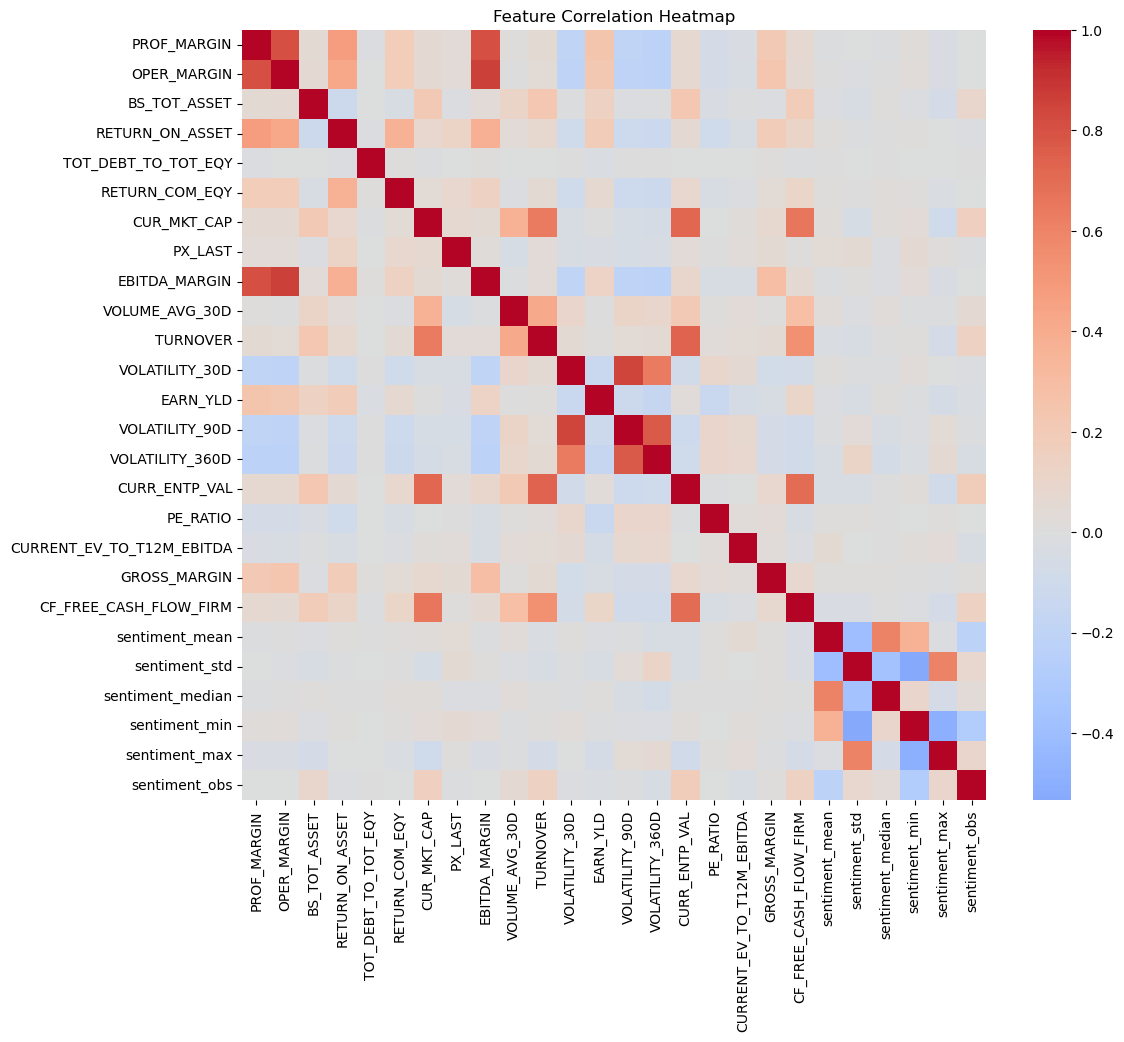

In [90]:
# =========================
# 4) CORRELATION HEATMAP
# =========================

import seaborn as sns
import matplotlib.pyplot as plt

corr = X.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [91]:
# =========================
# 5) RANDOM FOREST
# =========================

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

model.fit(X, y)

RandomForestRegressor(max_depth=6, n_estimators=300, n_jobs=-1, random_state=42)

In [93]:
# =========================
# 6) FEATURE IMPORTANCE
# =========================

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance.head(15))

,feature,importance
6,CUR_MKT_CAP,0.172286
7,PX_LAST,0.091918
17,CURRENT_EV_TO_T12M_EBITDA,0.086401
14,VOLATILITY_360D,0.081129
13,VOLATILITY_90D,0.077854
20,sentiment_mean,0.055593
9,VOLUME_AVG_30D,0.043226
2,BS_TOT_ASSET,0.038477
11,VOLATILITY_30D,0.038207
3,RETURN_ON_ASSET,0.037775


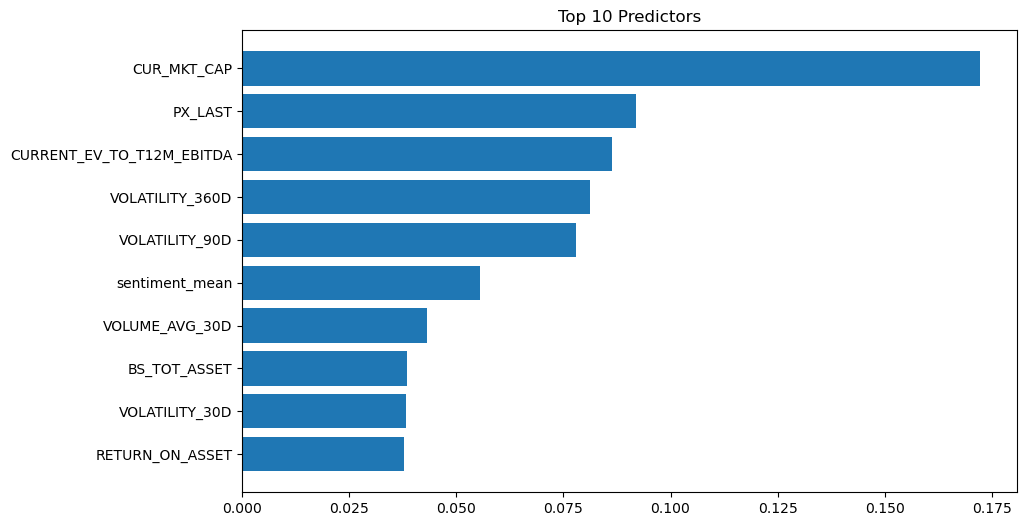

In [96]:
plt.figure(figsize=(10, 6))
plt.barh(importance["feature"].head(10), importance["importance"].head(10))
plt.gca().invert_yaxis()
plt.title("Top 10 Predictors")
plt.show()

In [98]:
# =========================
# 7) TOP FEATURES
# =========================

top_features = importance.head(6)["feature"].tolist()

print("Selected features:", top_features)

Selected features: ['CUR_MKT_CAP', 'PX_LAST', 'CURRENT_EV_TO_T12M_EBITDA', 'VOLATILITY_360D', 'VOLATILITY_90D', 'sentiment_mean']


In [100]:
# =========================
# 8) SCORE CREATION
# =========================

score_df = model_df.copy()

for col in top_features:
    score_df[col + "_z"] = (
        score_df.groupby("year")[col]
        .transform(lambda x: (x - x.mean()) / x.std())
    )

z_cols = [col + "_z" for col in top_features]

score_df["score"] = score_df[z_cols].mean(axis=1)

In [102]:
# =========================
# 9) QUINTILES
# =========================

score_df["quintile"] = score_df.groupby("year")["score"].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates="drop") + 1
)

In [104]:
# =========================
# 10) PERFORMANCE
# =========================

perf = score_df.groupby("quintile")["return_next_year"].mean()

print("Average return by quintile:")
print(perf)

Average return by quintile:
quintile
1.0    0.117681
2.0    0.143970
3.0    0.144506
4.0    0.183611
5.0    0.256824
Name: return_next_year, dtype: float64


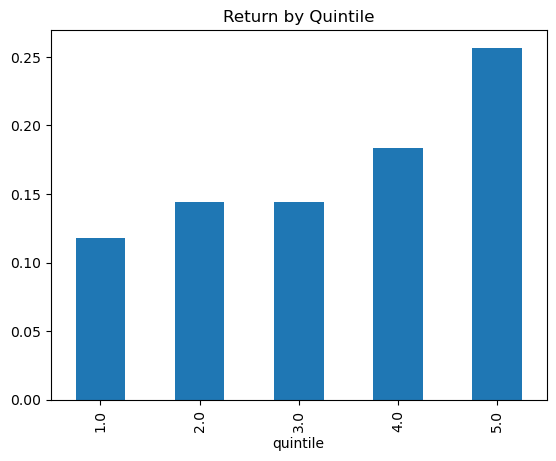

In [106]:
perf.plot(kind="bar", title="Return by Quintile")
plt.show()

In [108]:
print("Top quintile return:",
      score_df[score_df["quintile"] == 5]["return_next_year"].mean())

print("Market average:",
      score_df["return_next_year"].mean())

Top quintile return: 0.25682434238498103
Market average: 0.1694828633100635


In [110]:
# =========================
# 12) 2025 DATA
# =========================

portfolio_2025 = score_df[score_df["year"] == 2025].copy()

portfolio_2025 = portfolio_2025.sort_values("score", ascending=False)

In [112]:
# =========================
# 13) DIVERSIFIED PORTFOLIO
# =========================

final_portfolio = []
sector_counts = {}

for _, row in portfolio_2025.iterrows():
    sector = row["sector"]
    
    if sector not in sector_counts:
        sector_counts[sector] = 0
    
    if sector_counts[sector] < 5:
        final_portfolio.append(row)
        sector_counts[sector] += 1
    
    if len(final_portfolio) >= 50:
        break

final_portfolio_df = pd.DataFrame(final_portfolio)

print("Portfolio size:", len(final_portfolio_df))
print("\nSector distribution:")
print(final_portfolio_df["sector"].value_counts())

display(final_portfolio_df.head(20))

Portfolio size: 50

Sector distribution:
sector
Financials                5
Consumer Discretionary    5
Communication Services    5
Information Technology    5
Materials                 5
Industrials               5
Health Care               5
Energy                    5
Utilities                 3
Real Estate               3
Consumer Staples          1
Name: count, dtype: int64


,security,ticker,year,PROF_MARGIN,OPER_MARGIN,BS_TOT_ASSET,RETURN_ON_ASSET,TOT_DEBT_TO_TOT_EQY,RETURN_COM_EQY,CUR_MKT_CAP,PX_LAST,EBITDA_MARGIN,VOLUME_AVG_30D,TURNOVER,VOLATILITY_30D,EARN_YLD,VOLATILITY_90D,VOLATILITY_360D,CURR_ENTP_VAL,PE_RATIO,CURRENT_EV_TO_T12M_EBITDA,GROSS_MARGIN,CF_FREE_CASH_FLOW_FIRM,px_next_year,return_next_year,non_null_predictor_count,sentiment_mean,sentiment_std,sentiment_median,sentiment_min,sentiment_max,sentiment_obs,sector,CUR_MKT_CAP_z,PX_LAST_z,CURRENT_EV_TO_T12M_EBITDA_z,VOLATILITY_360D_z,VOLATILITY_90D_z,sentiment_mean_z,score,quintile
1530,COIN UW Equity,COIN,2025,3.0521,-5.2008,14753.901,0.1816,48.5025,1.6167,6.097725e+04,226.14,0.5922,3.100380e+06,6.158251e+10,67.035,0.9816,62.980,92.458,3.951699e+04,101.8712,2146.6127,NaN,2996.2317,NaN,NaN,18,-0.019707,0.126936,-0.0011,-0.7161,0.5164,261.0,Financials,-0.164190,-0.006613,16.263482,4.565365,2.162178,-0.536934,3.713881,5.0
1808,CVNA UN Equity,CVNA,2025,-11.6657,-17.1788,8698.000,-20.1998,1105.3333,-38.9273,8.864950e+04,422.02,-14.2752,3.029263e+06,1.799031e+10,221.371,-144.7598,191.969,137.420,8.758915e+03,NaN,101.8856,9.1591,NaN,NaN,NaN,17,0.059144,0.205425,0.0258,-0.7733,0.7909,249.0,Consumer Discretionary,-0.100137,0.415009,0.538481,7.946960,11.392030,1.835021,3.671227,5.0
4859,NVR UN Equity,NVR,2025,13.8165,18.2638,5834.475,21.3014,52.9853,40.5120,2.070732e+04,7292.77,18.8379,6.777000e+03,9.596823e+09,24.015,10.6634,37.171,32.961,1.322612e+04,9.3779,5.6698,24.4431,1265.8225,NaN,NaN,19,0.015087,0.118988,0.0000,-0.3336,0.5798,145.0,Consumer Discretionary,-0.257404,15.203939,-0.201468,0.090592,0.315407,0.509713,2.610130,5.0
918,BKNG UW Equity,BKNG,2025,10.6315,22.7779,23641.000,5.1192,184.8495,21.0460,1.726227e+05,5355.33,28.2807,1.239504e+05,7.528245e+10,29.010,4.6699,37.878,40.988,7.614848e+04,21.4137,13.3407,98.0916,2781.6041,NaN,NaN,19,0.028319,0.149740,0.0000,-0.5624,0.5729,230.0,Consumer Discretionary,0.094237,11.033701,-0.142475,0.694303,0.365996,0.907748,2.158918,5.0
3009,GOOG UW Equity,GOOG,2025,29.5117,30.5523,359268.000,22.3994,11.3291,32.0693,3.781633e+06,313.80,36.4288,7.445365e+06,2.688394e+11,32.869,NaN,41.184,34.997,1.061440e+06,NaN,NaN,56.9398,67301.9400,NaN,NaN,16,-0.007758,0.057754,-0.0018,-0.4396,0.3339,261.0,Communication Services,8.448055,0.182071,NaN,0.243719,0.602558,-0.177509,1.859779,5.0
4844,NVDA UW Equity,NVDA,2025,24.1100,27.9884,9841.000,19.3597,48.9413,32.5677,4.531950e+06,186.50,30.6946,1.356402e+08,1.500926e+11,35.356,1.3443,31.556,45.022,1.132830e+05,74.3890,53.4102,58.7988,1546.7234,NaN,NaN,19,-0.003459,0.163371,0.0097,-0.7462,0.6789,261.0,Information Technology,10.184822,-0.091936,0.165680,0.997700,-0.086377,-0.048169,1.853620,5.0
1874,DASH UW Equity,DASH,2025,-6.4621,-6.7053,10839.000,-5.4101,7.6618,-8.2301,9.761254e+04,226.48,0.4053,1.803681e+06,8.727515e+09,21.381,-1.0985,47.334,NaN,3.524686e+04,NaN,1007.0531,46.8558,NaN,NaN,NaN,16,0.020995,0.135304,0.0000,-0.8102,0.6915,237.0,Consumer Discretionary,-0.079390,-0.005881,7.499684,NaN,1.042624,0.687450,1.828897,5.0
1892,DDOG UW Equity,DDOG,2025,-2.9944,-3.5040,3004.852,-1.8627,59.3774,-4.0918,4.772131e+04,135.99,0.0684,1.029574e+06,3.225865e+10,21.559,0.1167,54.792,60.045,3.819928e+04,857.2518,836.4013,79.3002,NaN,NaN,NaN,18,0.034315,0.148311,0.0000,-0.7735,0.9397,201.0,Information Technology,-0.194874,-0.200656,6.187284,2.127581,1.576283,1.088140,1.763960,5.0
3024,GOOGL UW Equity,GOOGL,2025,29.5117,30.5523,359268.000,22.3994,11.3291,32.0693,3.781633e+06,313.00,36.4288,9.165149e+06,3.207582e+11,32.355,5.5125,40.574,34.939,1.061440e+06,18.1407,11.3317,56.9398,67301.9400,NaN,NaN,19,-0.007758,0.057754,-0.0018,-0.4396,0.3339,261.0,Communication Services,8.448055,0.180349,-0.157925,0.239357,0.558909,-0.177509,1.515206,5.0
4329,META UW Equity,META,2025,33.3845,39.6450,165987.000,24.2051,11.5744,31.1018,1.664132e+06,660.09,47.7067,7.578248e+06,3.650943e+11,46.718,9.2356,70.619,59.270,3.020952e+05,10.8277,7.6505,80.7944,39012.1505,NaN,NaN,19,-0.022789,0.085319,-0

In [114]:
final_portfolio_df.to_csv("portfolio_2026.csv", index=False)

In [116]:
# =========================
# HIT RATE
# =========================

hit_rate = (score_df["return_next_year"] > 0).mean()

print("Overall hit rate:", hit_rate)

# Top quintile hit rate
top_quintile = score_df[score_df["quintile"] == 5]

top_hit_rate = (top_quintile["return_next_year"] > 0).mean()

print("Top quintile hit rate:", top_hit_rate)

Overall hit rate: 0.6208204551840405
Top quintile hit rate: 0.6434782608695652


In [118]:
# =========================
# SHARPE RATIO
# =========================

returns = score_df[score_df["quintile"] == 5]["return_next_year"]

sharpe = returns.mean() / returns.std()

returns2 = score_df[score_df["quintile"] == 1]["return_next_year"]

sharpe2 = returns2.mean() / returns2.std()

print("Top quintile Sharpe ratio:", sharpe)
print("Bottom quintile Sharpe ratio:", sharpe2)

Top quintile Sharpe ratio: 0.4096400060928932
Bottom quintile Sharpe ratio: 0.4272960942624646


In [120]:
vw_returns = score_df.groupby("quintile").apply(
    lambda x: np.average(
        x.loc[x["return_next_year"].notna() & x["CUR_MKT_CAP"].notna(), "return_next_year"],
        weights=x.loc[x["return_next_year"].notna() & x["CUR_MKT_CAP"].notna(), "CUR_MKT_CAP"]
    )
)

print("Value-weighted returns by quintile:")
print(vw_returns)

Value-weighted returns by quintile:
quintile
1.0    0.077117
2.0    0.120346
3.0    0.082026
4.0    0.117890
5.0    0.210467
dtype: float64


In [122]:
# =========================
# MARKET COMPARISON
# =========================

top_return = score_df[score_df["quintile"] == 5]["return_next_year"].mean()
market_return = score_df["return_next_year"].mean()

print("Top quintile:", top_return)
print("Market average:", market_return)

Top quintile: 0.25682434238498103
Market average: 0.1694828633100635


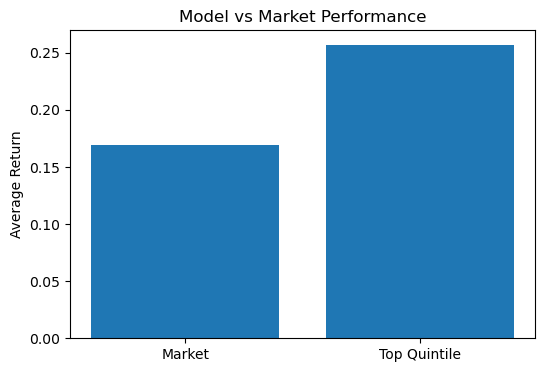

In [124]:
# =========================
# VISUAL COMPARISON
# =========================

labels = ["Market", "Top Quintile"]
values = [market_return, top_return]

plt.figure(figsize=(6, 4))
plt.bar(labels, values)
plt.title("Model vs Market Performance")
plt.ylabel("Average Return")
plt.show()

In [126]:
# =========================
# SENTIMENT ONLY MODEL
# =========================

sent_df = model_df.copy()

sent_df["sent_z"] = sent_df.groupby("year")["sentiment_mean"].transform(
    lambda x: (x - x.mean()) / x.std()
)

sent_df["sent_quintile"] = sent_df.groupby("year")["sent_z"].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates="drop") + 1
)

In [128]:
# =========================
# SENTIMENT PERFORMANCE
# =========================

sent_perf = sent_df.groupby("sent_quintile")["return_next_year"].mean()

print("Sentiment quintile returns:")
print(sent_perf)

Sentiment quintile returns:
sent_quintile
1.0    0.118066
2.0    0.132053
3.0    0.134401
4.0    0.153912
5.0    0.256468
Name: return_next_year, dtype: float64


In [130]:
print("Model top quintile:",
      score_df[score_df["quintile"] == 5]["return_next_year"].mean())

print("Sentiment top quintile:",
      sent_df[sent_df["sent_quintile"] == 5]["return_next_year"].mean())

Model top quintile: 0.25682434238498103
Sentiment top quintile: 0.256468102792037


In [132]:
# =========================
# QUINTILE SPREAD
# =========================

spread = (
    score_df[score_df["quintile"] == 5]["return_next_year"].mean()
    -
    score_df[score_df["quintile"] == 1]["return_next_year"].mean()
)

print("Q5 - Q1 spread:", spread)

Q5 - Q1 spread: 0.13914375832086573


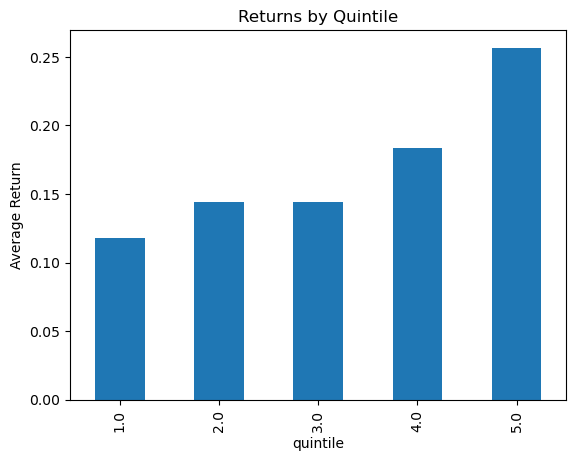

In [134]:
perf.plot(kind="bar", title="Returns by Quintile")
plt.ylabel("Average Return")
plt.show()

In [136]:
# =========================
# 1) EVALUATION FUNCTION
# =========================

import numpy as np
import pandas as pd

def evaluate_strategy(df, score_col, quintile_col_name="quintile_test"):
    temp = df.copy()

    temp = temp[temp[score_col].notna()].copy()

    temp[quintile_col_name] = temp.groupby("year")[score_col].transform(
        lambda x: pd.qcut(x, 5, labels=False, duplicates="drop") + 1
    )

    quintile_returns = temp.groupby(quintile_col_name)["return_next_year"].mean()

    q5 = temp[temp[quintile_col_name] == 5]["return_next_year"]
    q1 = temp[temp[quintile_col_name] == 1]["return_next_year"]

    top_hit_rate = (q5 > 0).mean()
    overall_hit_rate = (temp["return_next_year"] > 0).mean()
    spread = q5.mean() - q1.mean()
    sharpe_q5 = q5.mean() / q5.std() if q5.std() != 0 else np.nan

    return {
        "quintile_returns": quintile_returns,
        "top_quintile_return": q5.mean(),
        "bottom_quintile_return": q1.mean(),
        "spread_q5_q1": spread,
        "top_hit_rate": top_hit_rate,
        "overall_hit_rate": overall_hit_rate,
        "top_quintile_sharpe": sharpe_q5,
        "n_obs": len(temp)
    }

In [138]:
# =========================
# 2) BASE DATA
# =========================

eval_df = model_df[model_df["return_next_year"].notna()].copy()

print("Evaluation rows:", len(eval_df))

Evaluation rows: 6320


In [140]:
# =========================
# 3) RANDOM BASELINE
# =========================

np.random.seed(42)

eval_df["random_score"] = np.random.randn(len(eval_df))

random_results = evaluate_strategy(eval_df, "random_score", "random_quintile")

print("Random baseline quintile returns:")
print(random_results["quintile_returns"])
print("\nRandom Q5-Q1 spread:", random_results["spread_q5_q1"])
print("Random top hit rate:", random_results["top_hit_rate"])
print("Random top quintile Sharpe:", random_results["top_quintile_sharpe"])

Random baseline quintile returns:
random_quintile
1    0.168862
2    0.174939
3    0.159886
4    0.171176
5    0.172542
Name: return_next_year, dtype: float64

Random Q5-Q1 spread: 0.003679909618343913
Random top hit rate: 0.7000789265982637
Random top quintile Sharpe: 0.4109927075011002


In [142]:
# =========================
# 4A) SIMPLE FACTOR: EARNINGS YIELD
# =========================

eval_df["earn_yield_score"] = eval_df["EARN_YLD"]

earn_results = evaluate_strategy(eval_df, "earn_yield_score", "earn_quintile")

print("Earnings yield quintile returns:")
print(earn_results["quintile_returns"])
print("\nEarnings yield Q5-Q1 spread:", earn_results["spread_q5_q1"])
print("Earnings yield top hit rate:", earn_results["top_hit_rate"])
print("Earnings yield Sharpe:", earn_results["top_quintile_sharpe"])

Earnings yield quintile returns:
earn_quintile
1    0.218292
2    0.167057
3    0.150367
4    0.141954
5    0.155923
Name: return_next_year, dtype: float64

Earnings yield Q5-Q1 spread: -0.06236908480643988
Earnings yield top hit rate: 0.6816326530612244
Earnings yield Sharpe: 0.47251574895592086


In [144]:
# =========================
# 4B) SIMPLE FACTOR: LOW VOLATILITY
# =========================

eval_df["low_vol_score"] = -eval_df["VOLATILITY_90D"]

vol_results = evaluate_strategy(eval_df, "low_vol_score", "vol_quintile")

print("Low-vol quintile returns:")
print(vol_results["quintile_returns"])
print("\nLow-vol Q5-Q1 spread:", vol_results["spread_q5_q1"])
print("Low-vol top hit rate:", vol_results["top_hit_rate"])
print("Low-vol Sharpe:", vol_results["top_quintile_sharpe"])

Low-vol quintile returns:
vol_quintile
1    0.273052
2    0.188332
3    0.145520
4    0.116830
5    0.113641
Name: return_next_year, dtype: float64

Low-vol Q5-Q1 spread: -0.1594106954252948
Low-vol top hit rate: 0.7037643207855974
Low-vol Sharpe: 0.5076689482914228


In [230]:
# =========================
# FIX FEATURE SETS: REMOVE TEST STRATEGY COLUMNS
# =========================

base_exclude = [
    "security", "ticker", "year", "sector",
    "px_next_year", "return_next_year", "non_null_predictor_count",
    "random_score", "earn_yield_score", "low_vol_score",
    "random_quintile", "earn_quintile", "vol_quintile"
]

sentiment_cols = [
    "sentiment_mean", "sentiment_std", "sentiment_median",
    "sentiment_min", "sentiment_max", "sentiment_obs"
]

all_candidate_features = [
    c for c in eval_df.columns
    if c not in base_exclude and not c.endswith("_z")
]

features_with_sent = all_candidate_features.copy()
features_without_sent = [c for c in all_candidate_features if c not in sentiment_cols]

print("Features with sentiment:", len(features_with_sent))
print("Features without sentiment:", len(features_without_sent))
print(features_with_sent)

Features with sentiment: 26
Features without sentiment: 20
['PROF_MARGIN', 'OPER_MARGIN', 'BS_TOT_ASSET', 'RETURN_ON_ASSET', 'TOT_DEBT_TO_TOT_EQY', 'RETURN_COM_EQY', 'CUR_MKT_CAP', 'PX_LAST', 'EBITDA_MARGIN', 'VOLUME_AVG_30D', 'TURNOVER', 'VOLATILITY_30D', 'EARN_YLD', 'VOLATILITY_90D', 'VOLATILITY_360D', 'CURR_ENTP_VAL', 'PE_RATIO', 'CURRENT_EV_TO_T12M_EBITDA', 'GROSS_MARGIN', 'CF_FREE_CASH_FLOW_FIRM', 'sentiment_mean', 'sentiment_std', 'sentiment_median', 'sentiment_min', 'sentiment_max', 'sentiment_obs']


In [232]:
# =========================
# 5) FEATURE SETS
# =========================

base_exclude = [
    "security", "ticker", "year", "sector",
    "px_next_year", "return_next_year", "non_null_predictor_count"
]

sentiment_cols = [
    "sentiment_mean", "sentiment_std", "sentiment_median",
    "sentiment_min", "sentiment_max", "sentiment_obs"
]

all_candidate_features = [c for c in eval_df.columns if c not in base_exclude]

features_with_sent = all_candidate_features.copy()
features_without_sent = [c for c in all_candidate_features if c not in sentiment_cols]

print("Features with sentiment:", len(features_with_sent))
print("Features without sentiment:", len(features_without_sent))

Features with sentiment: 29
Features without sentiment: 23


In [234]:
# =========================
# 6) MODEL WITH SENTIMENT
# =========================

from sklearn.ensemble import RandomForestRegressor

X_with = eval_df[features_with_sent].copy()
y_with = eval_df["return_next_year"].copy()

X_with = X_with.fillna(X_with.median())

rf_with = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

rf_with.fit(X_with, y_with)

importance_with = pd.DataFrame({
    "feature": X_with.columns,
    "importance": rf_with.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_with.head(15))

top_with = importance_with.head(6)["feature"].tolist()
print("Top features WITH sentiment:", top_with)

,feature,importance
6,CUR_MKT_CAP,0.167980
7,PX_LAST,0.085793
17,CURRENT_EV_TO_T12M_EBITDA,0.084532
14,VOLATILITY_360D,0.076651
20,sentiment_mean,0.052765
13,VOLATILITY_90D,0.047440
9,VOLUME_AVG_30D,0.043356
28,low_vol_score,0.040855
11,VOLATILITY_30D,0.036383
3,RETURN_ON_ASSET,0.035631


Top features WITH sentiment: ['CUR_MKT_CAP', 'PX_LAST', 'CURRENT_EV_TO_T12M_EBITDA', 'VOLATILITY_360D', 'sentiment_mean', 'VOLATILITY_90D']


In [235]:
# =========================
# 6B) SCORE WITH SENTIMENT
# =========================

score_with_df = eval_df.copy()

for col in top_with:
    score_with_df[col + "_z_with"] = score_with_df.groupby("year")[col].transform(
        lambda x: (x - x.mean()) / x.std()
    )

score_with_df["score_with_sent"] = score_with_df[[c + "_z_with" for c in top_with]].mean(axis=1)

with_sent_results = evaluate_strategy(score_with_df, "score_with_sent", "quintile_with_sent")

print("WITH sentiment quintile returns:")
print(with_sent_results["quintile_returns"])
print("\nWITH sentiment spread:", with_sent_results["spread_q5_q1"])
print("WITH sentiment top hit rate:", with_sent_results["top_hit_rate"])
print("WITH sentiment Sharpe:", with_sent_results["top_quintile_sharpe"])

WITH sentiment quintile returns:
quintile_with_sent
1    0.118344
2    0.142790
3    0.145461
4    0.183648
5    0.257120
Name: return_next_year, dtype: float64

WITH sentiment spread: 0.13877609125735987
WITH sentiment top hit rate: 0.696921862667719
WITH sentiment Sharpe: 0.40940574865295143


In [238]:
# =========================
# 7) MODEL WITHOUT SENTIMENT
# =========================

X_without = eval_df[features_without_sent].copy()
y_without = eval_df["return_next_year"].copy()

X_without = X_without.fillna(X_without.median())

rf_without = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

rf_without.fit(X_without, y_without)

importance_without = pd.DataFrame({
    "feature": X_without.columns,
    "importance": rf_without.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_without.head(15))

top_without = importance_without.head(6)["feature"].tolist()
print("Top features WITHOUT sentiment:", top_without)

,feature,importance
6,CUR_MKT_CAP,0.180646
17,CURRENT_EV_TO_T12M_EBITDA,0.085513
14,VOLATILITY_360D,0.085076
7,PX_LAST,0.084088
20,random_score,0.056797
13,VOLATILITY_90D,0.053408
2,BS_TOT_ASSET,0.049394
9,VOLUME_AVG_30D,0.045726
22,low_vol_score,0.042895
15,CURR_ENTP_VAL,0.041237


Top features WITHOUT sentiment: ['CUR_MKT_CAP', 'CURRENT_EV_TO_T12M_EBITDA', 'VOLATILITY_360D', 'PX_LAST', 'random_score', 'VOLATILITY_90D']


In [239]:
# =========================
# 7B) SCORE WITHOUT SENTIMENT
# =========================

score_without_df = eval_df.copy()

for col in top_without:
    score_without_df[col + "_z_without"] = score_without_df.groupby("year")[col].transform(
        lambda x: (x - x.mean()) / x.std()
    )

score_without_df["score_without_sent"] = score_without_df[[c + "_z_without" for c in top_without]].mean(axis=1)

without_sent_results = evaluate_strategy(score_without_df, "score_without_sent", "quintile_without_sent")

print("WITHOUT sentiment quintile returns:")
print(without_sent_results["quintile_returns"])
print("\nWITHOUT sentiment spread:", without_sent_results["spread_q5_q1"])
print("WITHOUT sentiment top hit rate:", without_sent_results["top_hit_rate"])
print("WITHOUT sentiment Sharpe:", without_sent_results["top_quintile_sharpe"])

WITHOUT sentiment quintile returns:
quintile_without_sent
1    0.122218
2    0.144733
3    0.161030
4    0.175134
5    0.244280
Name: return_next_year, dtype: float64

WITHOUT sentiment spread: 0.12206253574893652
WITHOUT sentiment top hit rate: 0.7016574585635359
WITHOUT sentiment Sharpe: 0.39547807089404813


In [242]:
# =========================
# 8) COMPARISON TABLE
# =========================

comparison = pd.DataFrame([
    {
        "strategy": "Random",
        "top_quintile_return": random_results["top_quintile_return"],
        "spread_q5_q1": random_results["spread_q5_q1"],
        "top_hit_rate": random_results["top_hit_rate"],
        "top_quintile_sharpe": random_results["top_quintile_sharpe"]
    },
    {
        "strategy": "Earnings Yield",
        "top_quintile_return": earn_results["top_quintile_return"],
        "spread_q5_q1": earn_results["spread_q5_q1"],
        "top_hit_rate": earn_results["top_hit_rate"],
        "top_quintile_sharpe": earn_results["top_quintile_sharpe"]
    },
    {
        "strategy": "Low Volatility",
        "top_quintile_return": vol_results["top_quintile_return"],
        "spread_q5_q1": vol_results["spread_q5_q1"],
        "top_hit_rate": vol_results["top_hit_rate"],
        "top_quintile_sharpe": vol_results["top_quintile_sharpe"]
    },
    {
        "strategy": "Model WITHOUT Sentiment",
        "top_quintile_return": without_sent_results["top_quintile_return"],
        "spread_q5_q1": without_sent_results["spread_q5_q1"],
        "top_hit_rate": without_sent_results["top_hit_rate"],
        "top_quintile_sharpe": without_sent_results["top_quintile_sharpe"]
    },
    {
        "strategy": "Model WITH Sentiment",
        "top_quintile_return": with_sent_results["top_quintile_return"],
        "spread_q5_q1": with_sent_results["spread_q5_q1"],
        "top_hit_rate": with_sent_results["top_hit_rate"],
        "top_quintile_sharpe": with_sent_results["top_quintile_sharpe"]
    }
])

comparison = comparison.sort_values("spread_q5_q1", ascending=False)

display(comparison)

,strategy,top_quintile_return,spread_q5_q1,top_hit_rate,top_quintile_sharpe
4,Model WITH Sentiment,0.257120,0.138776,0.696922,0.409406
3,Model WITHOUT Sentiment,0.244280,0.122063,0.701657,0.395478
0,Random,0.172542,0.003680,0.700079,0.410993
1,Earnings Yield,0.155923,-0.062369,0.681633,0.472516
2,Low Volatility,0.113641,-0.159411,0.703764,0.507669


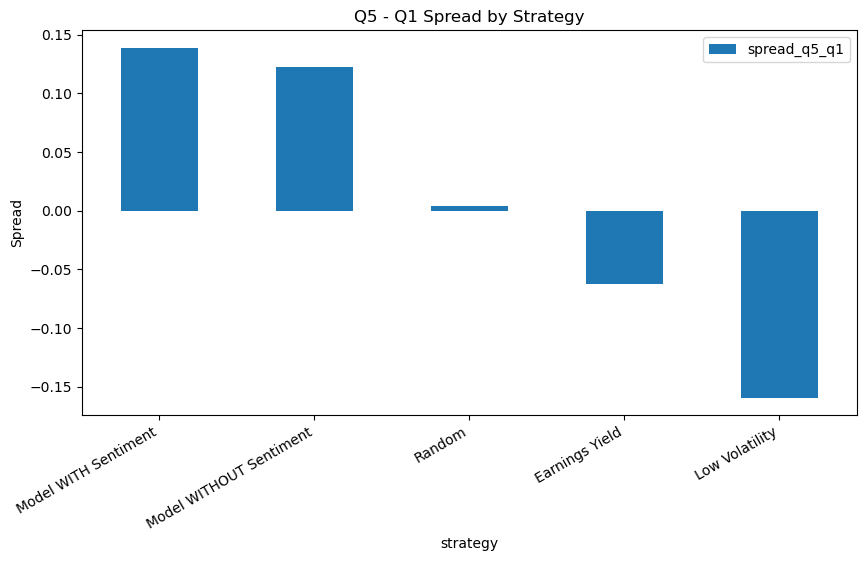

In [244]:
# =========================
# 9) VISUALIZE COMPARISON
# =========================

comparison.plot(
    x="strategy",
    y="spread_q5_q1",
    kind="bar",
    figsize=(10, 5),
    title="Q5 - Q1 Spread by Strategy"
)

plt.ylabel("Spread")
plt.xticks(rotation=30, ha="right")
plt.show()

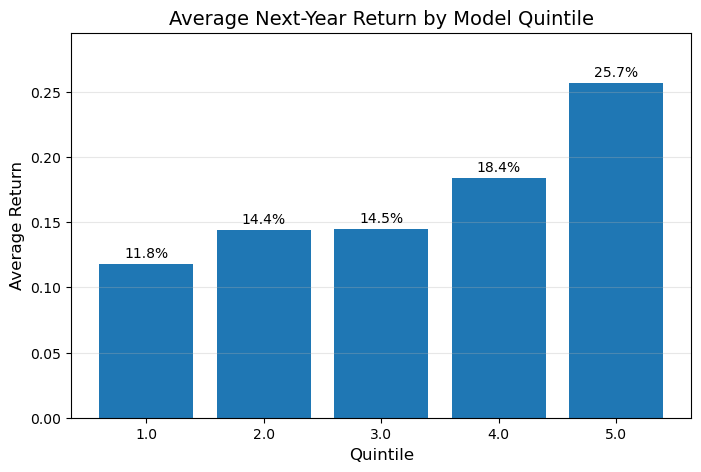

In [246]:
# =========================
# 1) QUINTILE RETURNS CHART
# =========================

quintile_returns = score_df.groupby("quintile")["return_next_year"].mean()

plt.figure(figsize=(8, 5))
bars = plt.bar(quintile_returns.index.astype(str), quintile_returns.values)

# highlight top quintile
bars[-1].set_linewidth(2)

plt.title("Average Next-Year Return by Model Quintile", fontsize=14)
plt.xlabel("Quintile", fontsize=12)
plt.ylabel("Average Return", fontsize=12)
plt.ylim(0, max(quintile_returns.values) * 1.15)
plt.grid(axis="y", alpha=0.3)

# add value labels
for i, v in enumerate(quintile_returns.values):
    plt.text(i, v + 0.005, f"{v:.1%}", ha="center", fontsize=10)

plt.show()

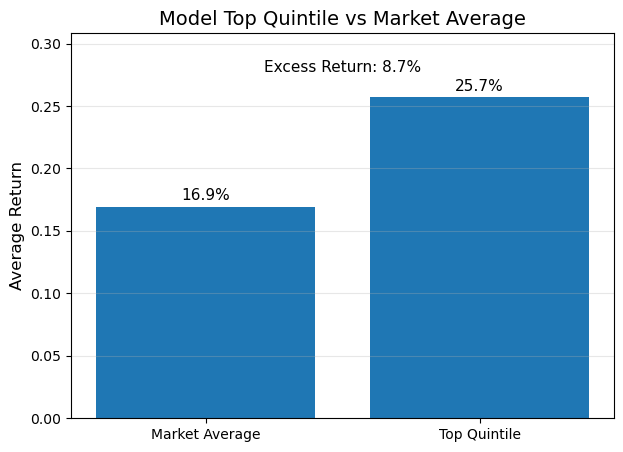

In [248]:
# =========================
# 2) Q5 VS MARKET
# =========================

q5_return = score_df[score_df["quintile"] == 5]["return_next_year"].mean()
market_return = score_df["return_next_year"].mean()

labels = ["Market Average", "Top Quintile"]
values = [market_return, q5_return]

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, values)

plt.title("Model Top Quintile vs Market Average", fontsize=14)
plt.ylabel("Average Return", fontsize=12)
plt.ylim(0, max(values) * 1.2)
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(values):
    plt.text(i, v + 0.005, f"{v:.1%}", ha="center", fontsize=11)

# optional excess return annotation
excess = q5_return - market_return
plt.text(0.5, max(values) * 1.08, f"Excess Return: {excess:.1%}", ha="center", fontsize=11)

plt.show()

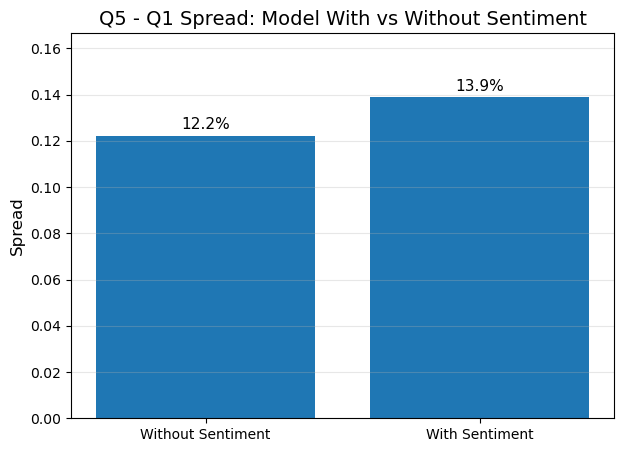

In [250]:
# =========================
# 3A) WITH VS WITHOUT SENTIMENT - SPREAD
# =========================

strategy_labels = ["Without Sentiment", "With Sentiment"]
strategy_spreads = [
    without_sent_results["spread_q5_q1"],
    with_sent_results["spread_q5_q1"]
]

plt.figure(figsize=(7, 5))
bars = plt.bar(strategy_labels, strategy_spreads)

plt.title("Q5 - Q1 Spread: Model With vs Without Sentiment", fontsize=14)
plt.ylabel("Spread", fontsize=12)
plt.ylim(0, max(strategy_spreads) * 1.2)
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(strategy_spreads):
    plt.text(i, v + 0.003, f"{v:.1%}", ha="center", fontsize=11)

plt.show()

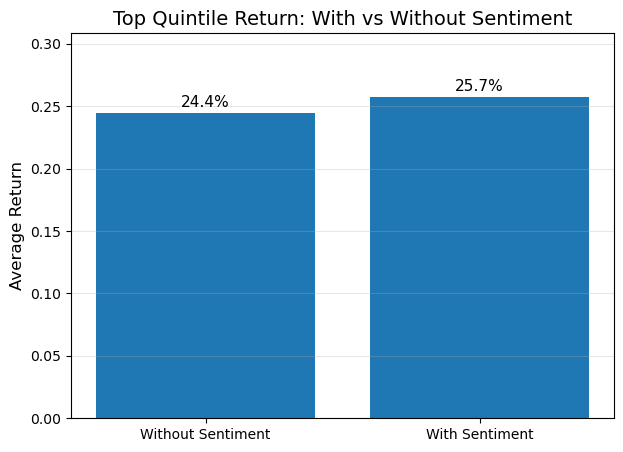

In [252]:
# =========================
# 3B) WITH VS WITHOUT SENTIMENT - TOP QUINTILE RETURN
# =========================

strategy_returns = [
    without_sent_results["top_quintile_return"],
    with_sent_results["top_quintile_return"]
]

plt.figure(figsize=(7, 5))
bars = plt.bar(strategy_labels, strategy_returns)

plt.title("Top Quintile Return: With vs Without Sentiment", fontsize=14)
plt.ylabel("Average Return", fontsize=12)
plt.ylim(0, max(strategy_returns) * 1.2)
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(strategy_returns):
    plt.text(i, v + 0.005, f"{v:.1%}", ha="center", fontsize=11)

plt.show()

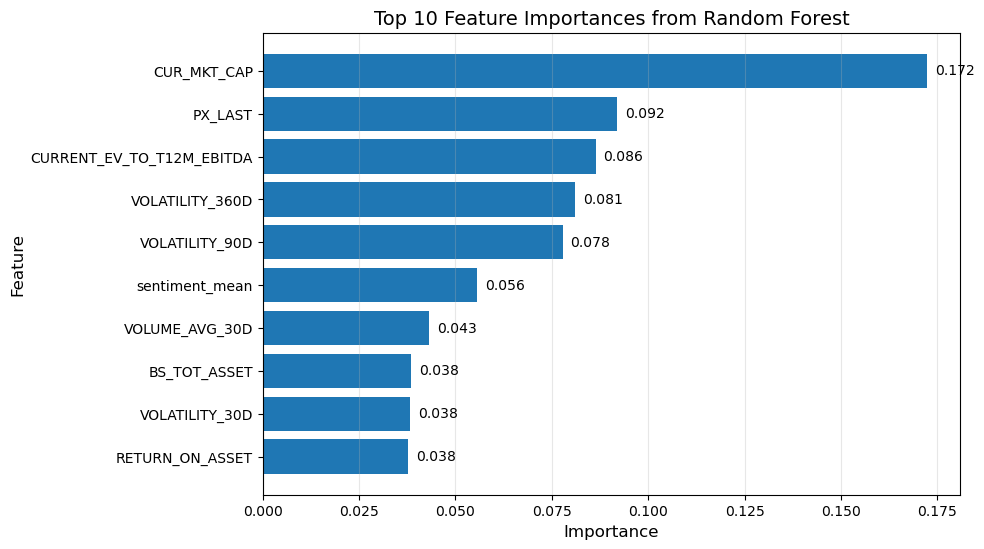

In [254]:
# =========================
# 4) FEATURE IMPORTANCE
# =========================

top_n = 10
importance_plot = importance.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(importance_plot["feature"], importance_plot["importance"])

plt.title("Top 10 Feature Importances from Random Forest", fontsize=14)
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.grid(axis="x", alpha=0.3)

for i, v in enumerate(importance_plot["importance"]):
    plt.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=10)

plt.show()

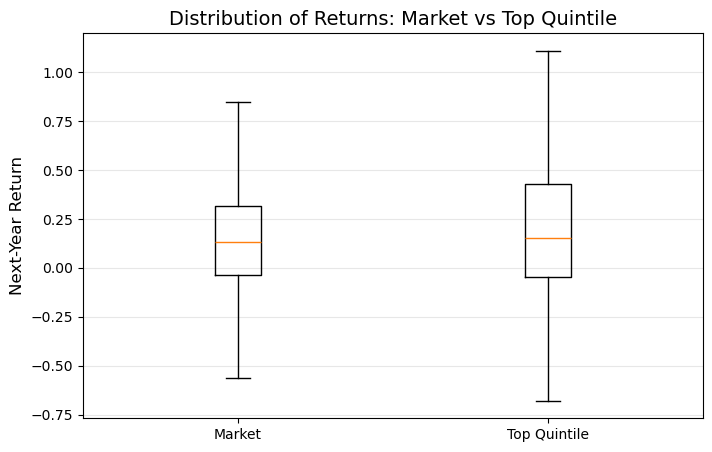

In [256]:
# =========================
# 5A) DISTRIBUTION - BOXPLOT
# =========================

market_returns = score_df["return_next_year"].dropna()
top_returns = score_df.loc[score_df["quintile"] == 5, "return_next_year"].dropna()

plt.figure(figsize=(8, 5))
plt.boxplot([market_returns, top_returns], tick_labels=["Market", "Top Quintile"], showfliers=False)

plt.title("Distribution of Returns: Market vs Top Quintile", fontsize=14)
plt.ylabel("Next-Year Return", fontsize=12)
plt.grid(axis="y", alpha=0.3)

plt.show()

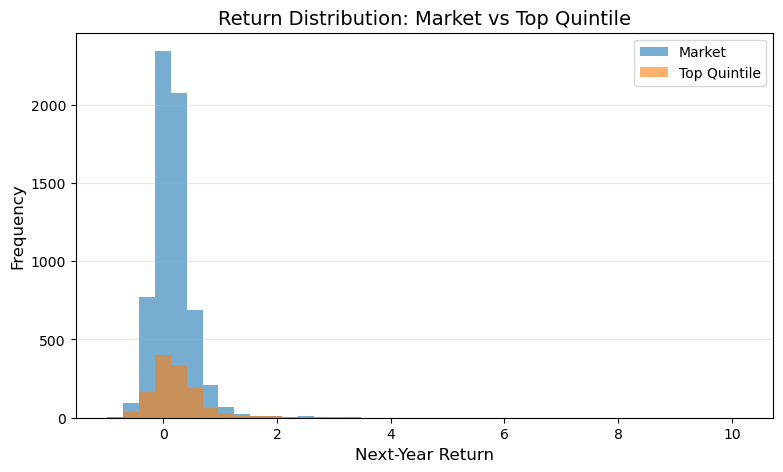

In [258]:
# =========================
# 5B) DISTRIBUTION - HISTOGRAM
# =========================

plt.figure(figsize=(9, 5))

plt.hist(market_returns, bins=40, alpha=0.6, label="Market")
plt.hist(top_returns, bins=40, alpha=0.6, label="Top Quintile")

plt.title("Return Distribution: Market vs Top Quintile", fontsize=14)
plt.xlabel("Next-Year Return", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

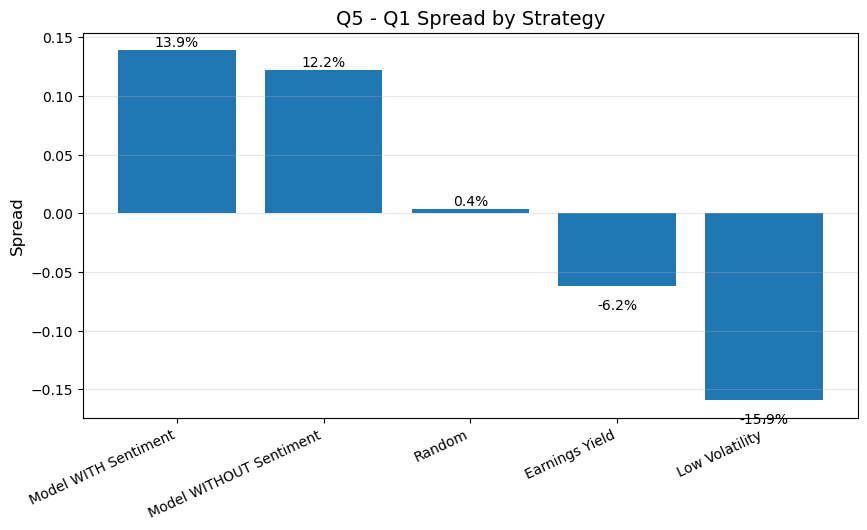

In [260]:
# =========================
# BONUS) STRATEGY COMPARISON
# =========================

comparison_plot = comparison.sort_values("spread_q5_q1", ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(comparison_plot["strategy"], comparison_plot["spread_q5_q1"])

plt.title("Q5 - Q1 Spread by Strategy", fontsize=14)
plt.ylabel("Spread", fontsize=12)
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(comparison_plot["spread_q5_q1"]):
    plt.text(i, v + 0.003 if v >= 0 else v - 0.02, f"{v:.1%}", ha="center", fontsize=10)

plt.show()

In [262]:
# =========================
# 1) YEARLY REBALANCED SIMULATION
# =========================

initial_investment = 1000

# yearly returns using year t signals to predict t+1 realized return
yearly_model = (
    score_df[score_df["quintile"] == 5]
    .groupby("year")["return_next_year"]
    .mean()
    .dropna()
)

yearly_market = (
    score_df.groupby("year")["return_next_year"]
    .mean()
    .dropna()
)

simulation_df = pd.DataFrame({
    "model_top_quintile_return": yearly_model,
    "market_return": yearly_market
}).dropna().sort_index()

# build wealth paths
simulation_df["model_value"] = initial_investment * (1 + simulation_df["model_top_quintile_return"]).cumprod()
simulation_df["market_value"] = initial_investment * (1 + simulation_df["market_return"]).cumprod()

display(simulation_df)

,model_top_quintile_return,market_return,model_value,market_value
year,,,,
2011,0.310469,0.201727,1310.469153,1201.726531
2012,0.517738,0.397718,1988.948786,1679.674648
2013,0.179624,0.167024,2346.210957,1960.220490
2014,0.087008,0.026064,2550.349045,2011.311455
2015,0.148350,0.157390,2928.692322,2327.871784
2016,0.317988,0.249949,3859.981004,2909.722029
2017,0.022227,-0.035749,3945.774935,2805.702815
2018,0.372241,0.321122,5414.552683,3706.675510
2019,0.393815,0.170067,7546.885961,4337.057564


In [264]:
# =========================
# 2) PRINT RESULTS
# =========================

start_year = simulation_df.index.min() + 1
end_year = simulation_df.index.max() + 1

final_model = simulation_df["model_value"].iloc[-1]
final_market = simulation_df["market_value"].iloc[-1]

print(f"If you invested ${initial_investment:,.0f} at the beginning of {start_year} and rebalanced yearly:")
print(f"- Model top quintile grows to: ${final_model:,.2f}")
print(f"- Market average grows to:     ${final_market:,.2f}")
print(f"- Difference:                  ${final_model - final_market:,.2f}")

If you invested $1,000 at the beginning of 2012 and rebalanced yearly:
- Model top quintile grows to: $20,579.96
- Market average grows to:     $8,321.74
- Difference:                  $12,258.22


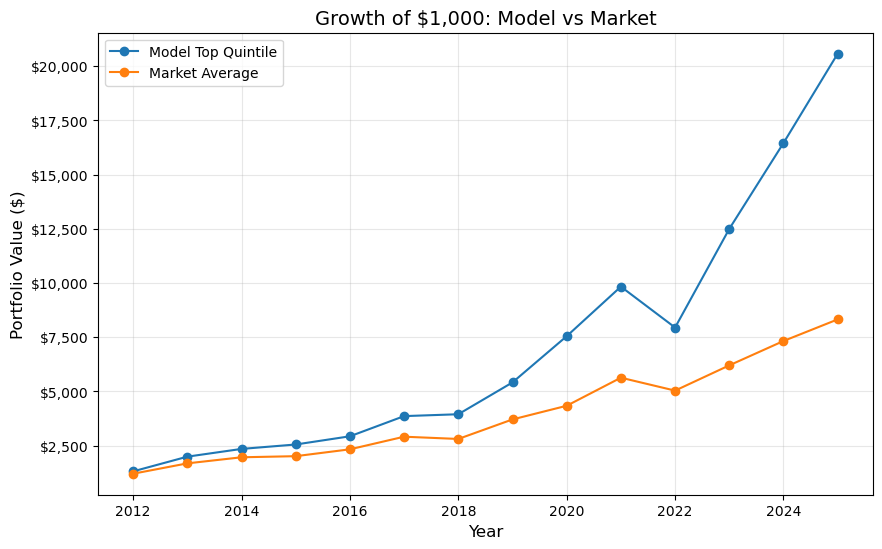

In [266]:
# =========================
# 3) PLOT PORTFOLIO GROWTH
# =========================

from matplotlib.ticker import StrMethodFormatter

plt.figure(figsize=(10, 6))

plt.plot(simulation_df.index + 1, simulation_df["model_value"], marker="o", label="Model Top Quintile")
plt.plot(simulation_df.index + 1, simulation_df["market_value"], marker="o", label="Market Average")

plt.title(f"Growth of ${initial_investment:,}: Model vs Market", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Portfolio Value ($)", fontsize=12)
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [268]:
# =========================
# 4) YEAR-BY-YEAR WALKTHROUGH
# =========================

simulation_table = simulation_df.copy()
simulation_table = simulation_table.reset_index()
simulation_table["investment_year"] = simulation_table["year"] + 1

simulation_table = simulation_table[[
    "investment_year",
    "model_top_quintile_return",
    "market_return",
    "model_value",
    "market_value"
]]

display(simulation_table)

,investment_year,model_top_quintile_return,market_return,model_value,market_value
0,2012,0.310469,0.201727,1310.469153,1201.726531
1,2013,0.517738,0.397718,1988.948786,1679.674648
2,2014,0.179624,0.167024,2346.210957,1960.220490
3,2015,0.087008,0.026064,2550.349045,2011.311455
4,2016,0.148350,0.157390,2928.692322,2327.871784
5,2017,0.317988,0.249949,3859.981004,2909.722029
6,2018,0.022227,-0.035749,3945.774935,2805.702815
7,2019,0.372241,0.321122,5414.552683,3706.675510
8,2020,0.393815,0.170067,7546.885961,4337.057564
9,2021,0.302992,0.298635,9833.535541,5632.253850


In [270]:
# =========================
# 5) TOP VS BOTTOM QUINTILE
# =========================

yearly_q5 = (
    score_df[score_df["quintile"] == 5]
    .groupby("year")["return_next_year"]
    .mean()
    .dropna()
)

yearly_q1 = (
    score_df[score_df["quintile"] == 1]
    .groupby("year")["return_next_year"]
    .mean()
    .dropna()
)

spread_sim = pd.DataFrame({
    "q5_return": yearly_q5,
    "q1_return": yearly_q1
}).dropna().sort_index()

spread_sim["q5_value"] = initial_investment * (1 + spread_sim["q5_return"]).cumprod()
spread_sim["q1_value"] = initial_investment * (1 + spread_sim["q1_return"]).cumprod()

display(spread_sim)

,q5_return,q1_return,q5_value,q1_value
year,,,,
2011,0.310469,0.119735,1310.469153,1119.735251
2012,0.517738,0.329808,1988.948786,1489.033451
2013,0.179624,0.188449,2346.210957,1769.640097
2014,0.087008,-0.011788,2550.349045,1748.780438
2015,0.148350,0.193148,2928.692322,2086.553744
2016,0.317988,0.166942,3859.981004,2434.888217
2017,0.022227,-0.017905,3945.774935,2391.290351
2018,0.372241,0.296112,5414.552683,3099.381243
2019,0.393815,0.075492,7546.885961,3333.359481


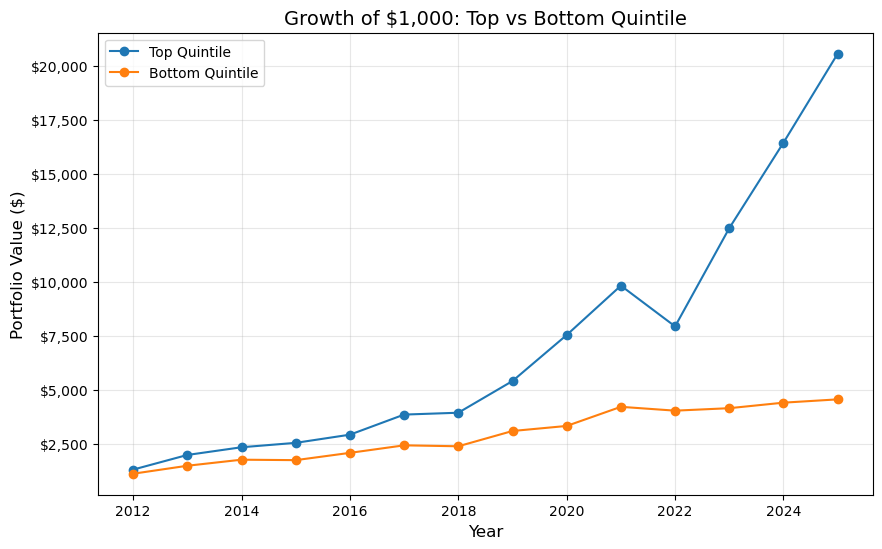

In [272]:
plt.figure(figsize=(10, 6))

plt.plot(spread_sim.index + 1, spread_sim["q5_value"], marker="o", label="Top Quintile")
plt.plot(spread_sim.index + 1, spread_sim["q1_value"], marker="o", label="Bottom Quintile")

plt.title(f"Growth of ${initial_investment:,}: Top vs Bottom Quintile", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Portfolio Value ($)", fontsize=12)
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [274]:
# =========================
# 6) WITH VS WITHOUT SENTIMENT
# =========================

# build yearly returns from the already-created scored datasets
score_with_df["quintile_with_sent"] = score_with_df.groupby("year")["score_with_sent"].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates="drop") + 1
)

score_without_df["quintile_without_sent"] = score_without_df.groupby("year")["score_without_sent"].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates="drop") + 1
)

yearly_with_sent = (
    score_with_df[score_with_df["quintile_with_sent"] == 5]
    .groupby("year")["return_next_year"]
    .mean()
    .dropna()
)

yearly_without_sent = (
    score_without_df[score_without_df["quintile_without_sent"] == 5]
    .groupby("year")["return_next_year"]
    .mean()
    .dropna()
)

sent_sim = pd.DataFrame({
    "with_sent_return": yearly_with_sent,
    "without_sent_return": yearly_without_sent
}).dropna().sort_index()

sent_sim["with_sent_value"] = initial_investment * (1 + sent_sim["with_sent_return"]).cumprod()
sent_sim["without_sent_value"] = initial_investment * (1 + sent_sim["without_sent_return"]).cumprod()

display(sent_sim)

,with_sent_return,without_sent_return,with_sent_value,without_sent_value
year,,,,
2011,0.310469,0.302913,1310.469153,1302.912655
2012,0.517738,0.516342,1988.948786,1975.661090
2013,0.173401,0.182190,2333.834796,2335.606384
2014,0.088019,0.092618,2539.257335,2551.924431
2015,0.150168,0.110032,2920.572949,2832.717593
2016,0.319152,0.305545,3852.680739,3698.239615
2017,0.025851,-0.013274,3952.276836,3649.148062
2018,0.372241,0.378284,5423.474856,5029.560817
2019,0.394621,0.404295,7563.693547,7062.986780


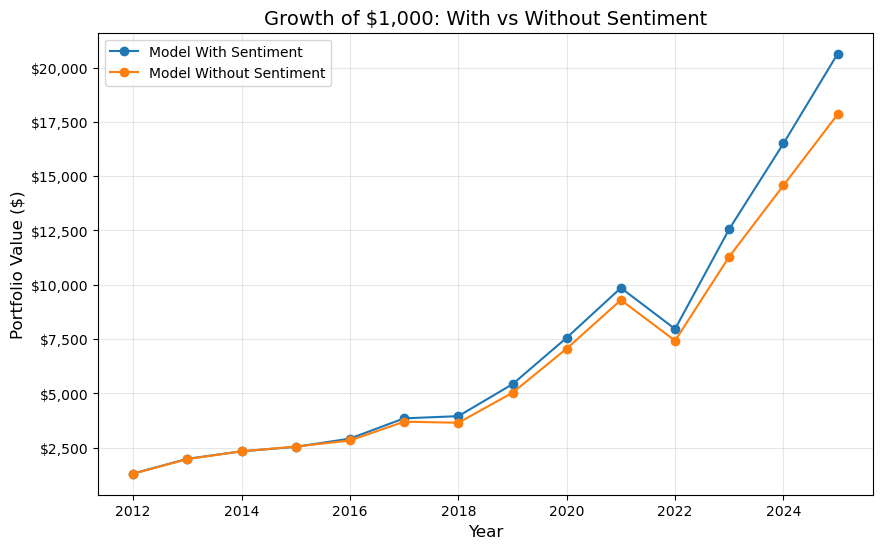

In [276]:
plt.figure(figsize=(10, 6))

plt.plot(sent_sim.index + 1, sent_sim["with_sent_value"], marker="o", label="Model With Sentiment")
plt.plot(sent_sim.index + 1, sent_sim["without_sent_value"], marker="o", label="Model Without Sentiment")

plt.title(f"Growth of ${initial_investment:,}: With vs Without Sentiment", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Portfolio Value ($)", fontsize=12)
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [278]:
# =========================
# 7) NARRATIVE SENTENCES
# =========================

for _, row in simulation_table.iterrows():
    print(
        f"At the beginning of {int(row['investment_year'])}, "
        f"${initial_investment:,.0f} invested in the model portfolio would grow to "
        f"${row['model_value']:,.2f} by year-end, versus "
        f"${row['market_value']:,.2f} for the market."
    )

At the beginning of 2012, $1,000 invested in the model portfolio would grow to $1,310.47 by year-end, versus $1,201.73 for the market.
At the beginning of 2013, $1,000 invested in the model portfolio would grow to $1,988.95 by year-end, versus $1,679.67 for the market.
At the beginning of 2014, $1,000 invested in the model portfolio would grow to $2,346.21 by year-end, versus $1,960.22 for the market.
At the beginning of 2015, $1,000 invested in the model portfolio would grow to $2,550.35 by year-end, versus $2,011.31 for the market.
At the beginning of 2016, $1,000 invested in the model portfolio would grow to $2,928.69 by year-end, versus $2,327.87 for the market.
At the beginning of 2017, $1,000 invested in the model portfolio would grow to $3,859.98 by year-end, versus $2,909.72 for the market.
At the beginning of 2018, $1,000 invested in the model portfolio would grow to $3,945.77 by year-end, versus $2,805.70 for the market.
At the beginning of 2019, $1,000 invested in the model 

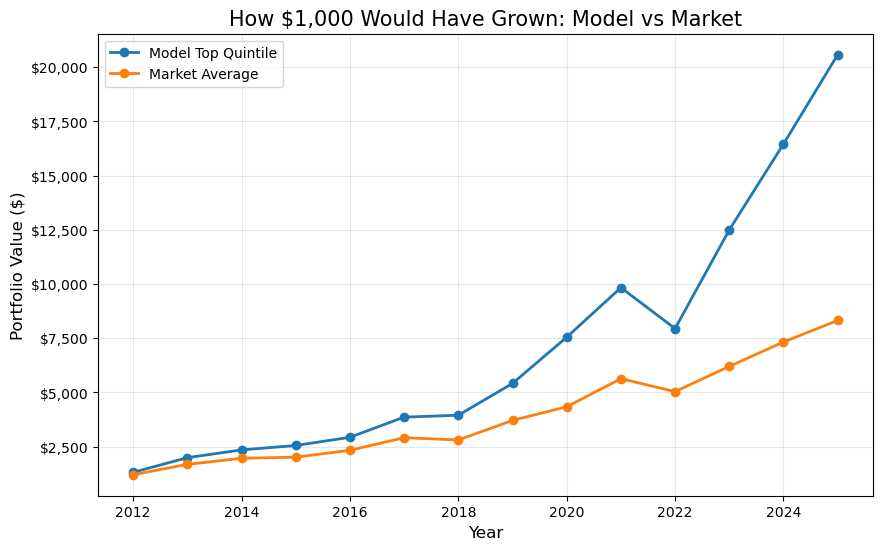

In [280]:
# =========================
# 8) BEST SINGLE SIMULATION CHART
# =========================

plt.figure(figsize=(10, 6))

plt.plot(simulation_df.index + 1, simulation_df["model_value"], marker="o", linewidth=2, label="Model Top Quintile")
plt.plot(simulation_df.index + 1, simulation_df["market_value"], marker="o", linewidth=2, label="Market Average")

plt.title("How $1,000 Would Have Grown: Model vs Market", fontsize=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Portfolio Value ($)", fontsize=12)
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [282]:
# =========================
# TOP PICKS TABLE
# =========================

display_cols = [
    "ticker",
    "sector",
    "score"
]

top_display = final_portfolio_df[display_cols].head(15)

top_display = top_display.sort_values("score", ascending=False)

top_display

,ticker,sector,score
1530,COIN,Financials,3.713881
1808,CVNA,Consumer Discretionary,3.671227
4859,NVR,Consumer Discretionary,2.610130
918,BKNG,Consumer Discretionary,2.158918
3009,GOOG,Communication Services,1.859779
4844,NVDA,Information Technology,1.853620
1874,DASH,Consumer Discretionary,1.828897
1892,DDOG,Information Technology,1.763960
3024,GOOGL,Communication Services,1.515206
4329,META,Communication Services,1.406049


In [284]:
top_display["score"] = top_display["score"].round(2)

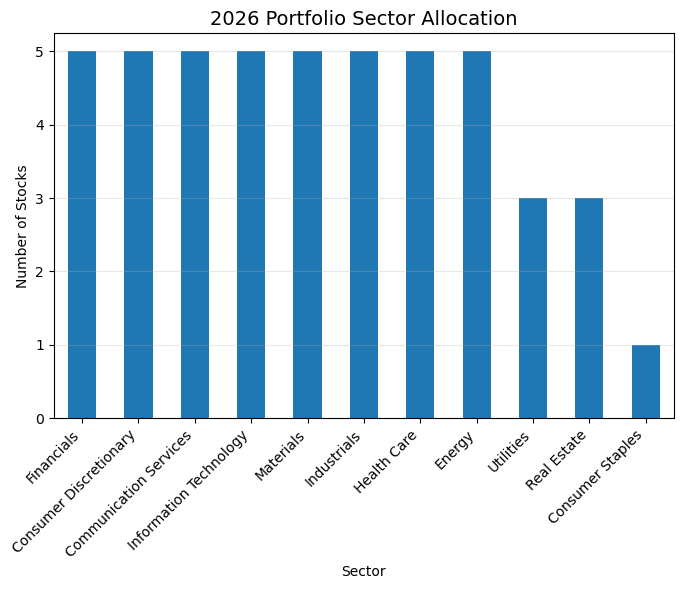

In [286]:
# =========================
# SECTOR DISTRIBUTION
# =========================

sector_counts = final_portfolio_df["sector"].value_counts()

plt.figure(figsize=(8, 5))
sector_counts.plot(kind="bar")

plt.title("2026 Portfolio Sector Allocation", fontsize=14)
plt.xlabel("Sector")
plt.ylabel("Number of Stocks")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.show()

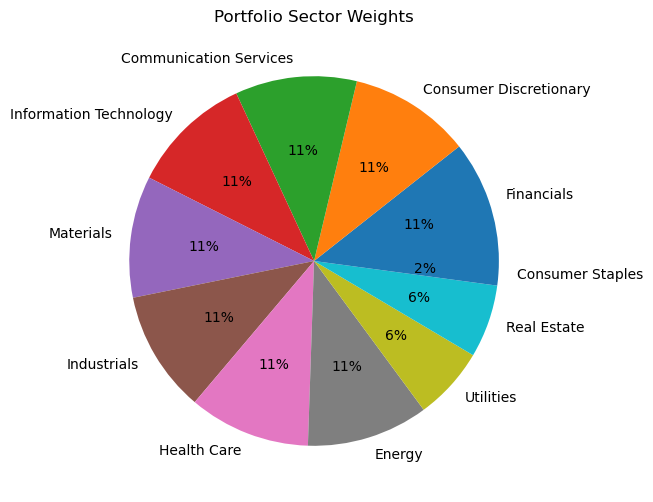

In [288]:
# =========================
# PIE CHART
# =========================

plt.figure(figsize=(6, 6))

final_portfolio_df["sector"].value_counts().plot(
    kind="pie",
    autopct="%1.0f%%"
)

plt.title("Portfolio Sector Weights")
plt.ylabel("")
plt.show()

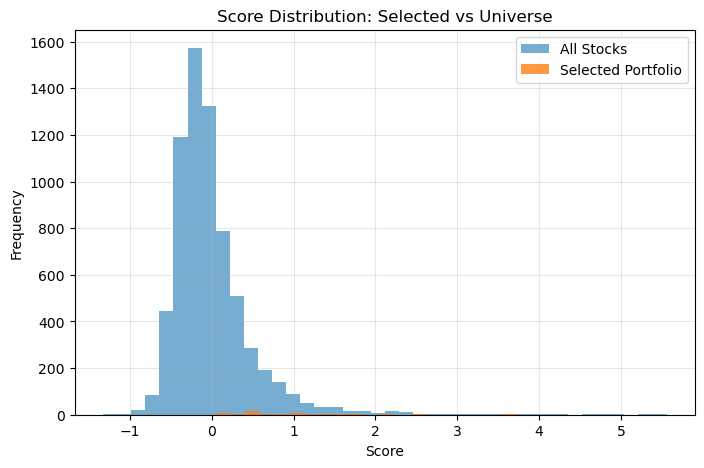

In [290]:
# =========================
# SCORE DISTRIBUTION
# =========================

plt.figure(figsize=(8, 5))

plt.hist(score_df["score"], bins=40, alpha=0.6, label="All Stocks")
plt.hist(final_portfolio_df["score"], bins=20, alpha=0.8, label="Selected Portfolio")

plt.title("Score Distribution: Selected vs Universe")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [292]:
# =========================
# PORTFOLIO SUMMARY
# =========================

print("Number of stocks:", len(final_portfolio_df))
print("Number of sectors:", final_portfolio_df["sector"].nunique())

print("\nTop sector exposure:")
print(final_portfolio_df["sector"].value_counts().head())

print("\nAverage score:", final_portfolio_df["score"].mean())

Number of stocks: 50
Number of sectors: 11

Top sector exposure:
sector
Financials                5
Consumer Discretionary    5
Communication Services    5
Information Technology    5
Materials                 5
Name: count, dtype: int64

Average score: 0.9258802370014032


In [294]:
final_portfolio_df.head(50)

,security,ticker,year,PROF_MARGIN,OPER_MARGIN,BS_TOT_ASSET,RETURN_ON_ASSET,TOT_DEBT_TO_TOT_EQY,RETURN_COM_EQY,CUR_MKT_CAP,PX_LAST,EBITDA_MARGIN,VOLUME_AVG_30D,TURNOVER,VOLATILITY_30D,EARN_YLD,VOLATILITY_90D,VOLATILITY_360D,CURR_ENTP_VAL,PE_RATIO,CURRENT_EV_TO_T12M_EBITDA,GROSS_MARGIN,CF_FREE_CASH_FLOW_FIRM,px_next_year,return_next_year,non_null_predictor_count,sentiment_mean,sentiment_std,sentiment_median,sentiment_min,sentiment_max,sentiment_obs,sector,CUR_MKT_CAP_z,PX_LAST_z,CURRENT_EV_TO_T12M_EBITDA_z,VOLATILITY_360D_z,VOLATILITY_90D_z,sentiment_mean_z,score,quintile
1530,COIN UW Equity,COIN,2025,3.0521,-5.2008,14753.901,0.1816,48.5025,1.6167,6.097725e+04,226.14,0.5922,3.100380e+06,6.158251e+10,67.035,0.9816,62.980,92.458,3.951699e+04,101.8712,2146.6127,NaN,2996.2317,NaN,NaN,18,-0.019707,0.126936,-0.00110,-0.7161,0.5164,261.0,Financials,-0.164190,-0.006613,16.263482,4.565365,2.162178,-0.536934,3.713881,5.0
1808,CVNA UN Equity,CVNA,2025,-11.6657,-17.1788,8698.000,-20.1998,1105.3333,-38.9273,8.864950e+04,422.02,-14.2752,3.029263e+06,1.799031e+10,221.371,-144.7598,191.969,137.420,8.758915e+03,NaN,101.8856,9.1591,NaN,NaN,NaN,17,0.059144,0.205425,0.02580,-0.7733,0.7909,249.0,Consumer Discretionary,-0.100137,0.415009,0.538481,7.946960,11.392030,1.835021,3.671227,5.0
4859,NVR UN Equity,NVR,2025,13.8165,18.2638,5834.475,21.3014,52.9853,40.5120,2.070732e+04,7292.77,18.8379,6.777000e+03,9.596823e+09,24.015,10.6634,37.171,32.961,1.322612e+04,9.3779,5.6698,24.4431,1265.8225,NaN,NaN,19,0.015087,0.118988,0.00000,-0.3336,0.5798,145.0,Consumer Discretionary,-0.257404,15.203939,-0.201468,0.090592,0.315407,0.509713,2.610130,5.0
918,BKNG UW Equity,BKNG,2025,10.6315,22.7779,23641.000,5.1192,184.8495,21.0460,1.726227e+05,5355.33,28.2807,1.239504e+05,7.528245e+10,29.010,4.6699,37.878,40.988,7.614848e+04,21.4137,13.3407,98.0916,2781.6041,NaN,NaN,19,0.028319,0.149740,0.00000,-0.5624,0.5729,230.0,Consumer Discretionary,0.094237,11.033701,-0.142475,0.694303,0.365996,0.907748,2.158918,5.0
3009,GOOG UW Equity,GOOG,2025,29.5117,30.5523,359268.000,22.3994,11.3291,32.0693,3.781633e+06,313.80,36.4288,7.445365e+06,2.688394e+11,32.869,NaN,41.184,34.997,1.061440e+06,NaN,NaN,56.9398,67301.9400,NaN,NaN,16,-0.007758,0.057754,-0.00180,-0.4396,0.3339,261.0,Communication Services,8.448055,0.182071,NaN,0.243719,0.602558,-0.177509,1.859779,5.0
4844,NVDA UW Equity,NVDA,2025,24.1100,27.9884,9841.000,19.3597,48.9413,32.5677,4.531950e+06,186.50,30.6946,1.356402e+08,1.500926e+11,35.356,1.3443,31.556,45.022,1.132830e+05,74.3890,53.4102,58.7988,1546.7234,NaN,NaN,19,-0.003459,0.163371,0.00970,-0.7462,0.6789,261.0,Information Technology,10.184822,-0.091936,0.165680,0.997700,-0.086377,-0.048169,1.853620,5.0
1874,DASH UW Equity,DASH,2025,-6.4621,-6.7053,10839.000,-5.4101,7.6618,-8.2301,9.761254e+04,226.48,0.4053,1.803681e+06,8.727515e+09,21.381,-1.0985,47.334,NaN,3.524686e+04,NaN,1007.0531,46.8558,NaN,NaN,NaN,16,0.020995,0.135304,0.00000,-0.8102,0.6915,237.0,Consumer Discretionary,-0.079390,-0.005881,7.499684,NaN,1.042624,0.687450,1.828897,5.0
1892,DDOG UW Equity,DDOG,2025,-2.9944,-3.5040,3004.852,-1.8627,59.3774,-4.0918,4.772131e+04,135.99,0.0684,1.029574e+06,3.225865e+10,21.559,0.1167,54.792,60.045,3.819928e+04,857.2518,836.4013,79.3002,NaN,NaN,NaN,18,0.034315,0.148311,0.00000,-0.7735,0.9397,201.0,Information Technology,-0.194874,-0.200656,6.187284,2.127581,1.576283,1.088140,1.763960,5.0
3024,GOOGL UW Equity,GOOGL,2025,29.5117,30.5523,359268.000,22.3994,11.3291,32.0693,3.781633e+06,313.00,36.4288,9.165149e+06,3.207582e+11,32.355,5.5125,40.574,34.939,1.061440e+06,18.1407,11.3317,56.9398,67301.9400,NaN,NaN,19,-0.007758,0.057754,-0.00180,-0.4396,0.3339,261.0,Communication Services,8.448055,0.180349,-0.157925,0.239357,0.558909,-0.177509,1.515206,5.0
4329,META UW Equity,META,2025,33.3845,39.6450,165987.000,24.2051,11.5744,31.1018,1.664132e+06,660.09,47.7067,7.578248e+06,3.650943e+11,46.718,9.2356,70.619,59.270,3.020952e+05,10.8277,7.6505,80.7944,39012.1505,NaN,NaN,19,-0.022789,0.

# Regression

In [297]:
# =========================
# REGRESSION ANALYSIS
# =========================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Use only rows where next-year return is known
reg_df = model_df[model_df["return_next_year"].notna()].copy()

# Make sure sector exists
reg_df["sector"] = reg_df["sector"].fillna("Unknown")

# Winsorize returns to reduce effect of extreme outliers
lower = reg_df["return_next_year"].quantile(0.01)
upper = reg_df["return_next_year"].quantile(0.99)
reg_df["return_next_year_w"] = reg_df["return_next_year"].clip(lower, upper)

print("Regression sample size:", len(reg_df))
print("Years:", sorted(reg_df["year"].unique()))

Regression sample size: 6320
Years: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [299]:
# =========================
# HELPER: STANDARDIZE BY YEAR
# =========================

def zscore_by_year(df, cols):
    df = df.copy()
    for col in cols:
        df[col + "_z"] = df.groupby("year")[col].transform(
            lambda x: (x - x.mean()) / x.std()
        )
    return df

# Core variables based on your Random Forest feature importance
core_vars = [
    "CUR_MKT_CAP",
    "PX_LAST",
    "CURRENT_EV_TO_T12M_EBITDA",
    "VOLATILITY_360D",
    "VOLATILITY_90D"
]

sentiment_vars = [
    "sentiment_mean"
]

reg_df = zscore_by_year(reg_df, core_vars + sentiment_vars)

# Log-transform size variables for interpretability
reg_df["log_mkt_cap"] = np.log1p(reg_df["CUR_MKT_CAP"])
reg_df["log_price"] = np.log1p(reg_df["PX_LAST"])
reg_df["log_volume"] = np.log1p(reg_df["VOLUME_AVG_30D"])

In [301]:
# =========================
# REGRESSION 1: CORE FACTORS ONLY
# =========================

reg1_formula = """
return_next_year_w ~ 
    CUR_MKT_CAP_z
    + PX_LAST_z
    + CURRENT_EV_TO_T12M_EBITDA_z
    + VOLATILITY_360D_z
    + VOLATILITY_90D_z
    + C(year)
"""

reg1 = smf.ols(reg1_formula, data=reg_df).fit(cov_type="HC3")

print(reg1.summary())

                            OLS Regression Results                            
Dep. Variable:     return_next_year_w   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     73.94
Date:                Tue, 28 Apr 2026   Prob (F-statistic):          2.31e-242
Time:                        14:15:06   Log-Likelihood:                -694.49
No. Observations:                5528   AIC:                             1427.
Df Residuals:                    5509   BIC:                             1553.
Df Model:                          18                                         
Covariance Type:                  HC3                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [303]:
# =========================
# REGRESSION 2: CORE FACTORS + SENTIMENT
# =========================

reg2_df = reg_df[reg_df["sentiment_mean"].notna()].copy()

reg2_formula = """
return_next_year_w ~ 
    CUR_MKT_CAP_z
    + PX_LAST_z
    + CURRENT_EV_TO_T12M_EBITDA_z
    + VOLATILITY_360D_z
    + VOLATILITY_90D_z
    + sentiment_mean_z
    + C(year)
"""

reg2 = smf.ols(reg2_formula, data=reg2_df).fit(cov_type="HC3")

print(reg2.summary())

                            OLS Regression Results                            
Dep. Variable:     return_next_year_w   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     5.532
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           3.04e-06
Time:                        14:15:07   Log-Likelihood:                -238.25
No. Observations:                 873   AIC:                             492.5
Df Residuals:                     865   BIC:                             530.7
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [305]:
# =========================
# REGRESSION 3: YEAR + SECTOR CONTROLS
# =========================

reg3_formula = """
return_next_year_w ~ 
    CUR_MKT_CAP_z
    + PX_LAST_z
    + CURRENT_EV_TO_T12M_EBITDA_z
    + VOLATILITY_360D_z
    + VOLATILITY_90D_z
    + sentiment_mean_z
    + C(year)
    + C(sector)
"""

reg3 = smf.ols(reg3_formula, data=reg2_df).fit(cov_type="HC3")

print(reg3.summary())

                            OLS Regression Results                            
Dep. Variable:     return_next_year_w   R-squared:                       0.142
Model:                            OLS   Adj. R-squared:                  0.123
Method:                 Least Squares   F-statistic:                     5.647
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           8.08e-13
Time:                        14:15:07   Log-Likelihood:                -202.38
No. Observations:                 873   AIC:                             442.8
Df Residuals:                     854   BIC:                             533.4
Df Model:                          18                                         
Covariance Type:                  HC3                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

In [307]:
# =========================
# REGRESSION 4: TOP QUINTILE EFFECT
# =========================

quintile_reg_df = score_df[score_df["return_next_year"].notna()].copy()
quintile_reg_df["sector"] = quintile_reg_df["sector"].fillna("Unknown")

# Winsorize returns
lower = quintile_reg_df["return_next_year"].quantile(0.01)
upper = quintile_reg_df["return_next_year"].quantile(0.99)
quintile_reg_df["return_next_year_w"] = quintile_reg_df["return_next_year"].clip(lower, upper)

# Top quintile dummy
quintile_reg_df["top_quintile"] = (quintile_reg_df["quintile"] == 5).astype(int)

reg4_formula = """
return_next_year_w ~ 
    top_quintile
    + C(year)
    + C(sector)
"""

reg4 = smf.ols(reg4_formula, data=quintile_reg_df).fit(cov_type="HC3")

print(reg4.summary())

                            OLS Regression Results                            
Dep. Variable:     return_next_year_w   R-squared:                       0.205
Model:                            OLS   Adj. R-squared:                  0.202
Method:                 Least Squares   F-statistic:                     67.37
Date:                Tue, 28 Apr 2026   Prob (F-statistic):          1.77e-300
Time:                        14:15:08   Log-Likelihood:                -810.96
No. Observations:                6320   AIC:                             1674.
Df Residuals:                    6294   BIC:                             1849.
Df Model:                          25                                         
Covariance Type:                  HC3                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

In [309]:
# =========================
# REGRESSION 5: MODEL SCORE PREDICTING RETURNS
# =========================

score_reg_df = score_df[score_df["return_next_year"].notna()].copy()
score_reg_df["sector"] = score_reg_df["sector"].fillna("Unknown")

lower = score_reg_df["return_next_year"].quantile(0.01)
upper = score_reg_df["return_next_year"].quantile(0.99)
score_reg_df["return_next_year_w"] = score_reg_df["return_next_year"].clip(lower, upper)

score_reg_df["score_z"] = score_reg_df.groupby("year")["score"].transform(
    lambda x: (x - x.mean()) / x.std()
)

reg5_formula = """
return_next_year_w ~ 
    score_z
    + C(year)
    + C(sector)
"""

reg5 = smf.ols(reg5_formula, data=score_reg_df).fit(cov_type="HC3")

print(reg5.summary())

                            OLS Regression Results                            
Dep. Variable:     return_next_year_w   R-squared:                       0.209
Model:                            OLS   Adj. R-squared:                  0.205
Method:                 Least Squares   F-statistic:                     67.97
Date:                Tue, 28 Apr 2026   Prob (F-statistic):          5.46e-303
Time:                        14:15:08   Log-Likelihood:                -796.52
No. Observations:                6320   AIC:                             1645.
Df Residuals:                    6294   BIC:                             1821.
Df Model:                          25                                         
Covariance Type:                  HC3                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

In [311]:
# =========================
# CLEAN REGRESSION SUMMARY TABLE
# =========================

from statsmodels.iolib.summary2 import summary_col

summary_table = summary_col(
    [reg1, reg2, reg3, reg4, reg5],
    model_names=[
        "Core Factors",
        "Add Sentiment",
        "Sector Controls",
        "Top Quintile",
        "Score"
    ],
    stars=True,
    float_format="%0.4f",
    info_dict={
        "N": lambda x: f"{int(x.nobs)}",
        "R2": lambda x: f"{x.rsquared:.3f}"
    }
)

print(summary_table)


                                    Core Factors Add Sentiment Sector Controls Top Quintile   Score   
------------------------------------------------------------------------------------------------------
Intercept                           0.1949***    0.1595***     0.2781***       0.2317***    0.2387*** 
                                    (0.0117)     (0.0156)      (0.0607)        (0.0245)     (0.0242)  
C(year)[T.2012]                     0.1698***                                  0.1806***    0.1807*** 
                                    (0.0196)                                   (0.0189)     (0.0189)  
C(year)[T.2013]                     -0.0266                                    -0.0333**    -0.0332** 
                                    (0.0163)                                   (0.0161)     (0.0161)  
C(year)[T.2014]                     -0.1646***                                 -0.1718***   -0.1716***
                                    (0.0171)                            

In [317]:
# =========================
# CLEAN SLIDE-READY REGRESSION TABLE
# =========================

table_data = [
    ["Model Score (z)", f"{reg5.params['score_z']:.3f}***", f"({reg5.bse['score_z']:.3f})"],
    ["Top Quintile", f"{reg4.params['top_quintile']:.3f}***", f"({reg4.bse['top_quintile']:.3f})"],
    ["Sentiment (z)", f"{reg3.params['sentiment_mean_z']:.3f}***", f"({reg3.bse['sentiment_mean_z']:.3f})"],
    ["", "", ""],
    ["R²", f"{reg5.rsquared:.3f}", ""],
    ["Observations", f"{int(reg5.nobs)}", ""]
]

reg_table = pd.DataFrame(table_data, columns=["Variable", "Coefficient", "Std Error"])

print(reg_table)

          Variable Coefficient Std Error
0  Model Score (z)    0.029***   (0.005)
1     Top Quintile    0.052***   (0.011)
2    Sentiment (z)    0.035***   (0.012)
3                                       
4               R²       0.209          
5     Observations        6320          
